# 14 — Generate paper figures from pipeline products

This notebook generates the manuscript figures from products written by
Notebooks 01–13. It does not repeat response correction, geometry derivation,
weather analysis, catalogue construction, array analysis, or key-event
measurement.

All scientific parameters used below are read from the numbered pipeline
products. Notebook-local values are limited to figure styling and display
windows.


## Pipeline-product figure generation

Required upstream products are validated at the start. The notebook uses the
canonical D* channel convention:

- DD1, DD2, DD3: infrasound
- DHE, DHN, DHZ: seismic

Legacy H* channel codes are not used in this notebook.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys
import warnings
from pprint import pprint

project_root = Path.cwd().resolve()
if project_root.name in {"notebooks", "notebooks2"}:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from obspy import Stream, Trace, UTCDateTime, read, read_inventory
from pyproj import Geod, Transformer

from modules import project_config as config
from modules.kml_utils import read_kml_points
from modules.xml_utils import (
    inventory_channels_to_dataframe,
    inventory_stations_to_dataframe,
    load_station_sensor_dataframe,
)
from modules.figure1_utils import (
    get_sensor_location,
    make_figure1,
    save_figure,
)

PROJECT_ROOT = config.PROJECT_ROOT
OUTDIR = config.OUTPUT_DIR / "14_paper_figures"
OUTDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
})


## 2. Load authoritative pipeline products

This cell is the single source of paths and scientific parameters for all
figures below.


In [2]:
# -----------------------------------------------------------------------------
# Required numbered products
# -----------------------------------------------------------------------------
ANALYSIS_CONFIG_FILE = config.OUTPUT_DIR / "02_analysis_configuration.json"
WEATHER_FILE = config.OUTPUT_DIR / "03_weather_acoustic_summary.csv"
CATALOGUE_FILE = config.OUTPUT_DIR / "04_final_153_event_catalogue.csv"
PLANAR_RESULTS_FILE = (
    config.OUTPUT_DIR
    / "array_analysis_planar_refined"
    / "planar_array_results.csv"
)
PLANAR_SUMMARY_FILE = (
    config.OUTPUT_DIR
    / "array_analysis_planar_refined"
    / "planar_refined_solution_summaries.csv"
)
KEY_EVENT_PRESSURES_FILE = (
    config.DERIVED_DIR / "key_event_pressure_measurements.csv"
)
KEY_EVENT_WINDOWS_FILE = (
    config.DERIVED_DIR / "key_event_measurement_windows.csv"
)
KEY_EVENT_METADATA_FILE = (
    config.DERIVED_DIR / "key_event_measurement_metadata.json"
)
VIDEO_SYNC_FILE = (
    config.OUTPUT_DIR
    / "13_synchronized_video"
    / "13_video_sync_configuration.json"
)

for required in (
    ANALYSIS_CONFIG_FILE,
    WEATHER_FILE,
    CATALOGUE_FILE,
):
    if not required.exists():
        raise FileNotFoundError(
            f"Required pipeline product not found: {required}"
        )

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
weather_summary = pd.read_csv(WEATHER_FILE).iloc[0]
catalogue = pd.read_csv(CATALOGUE_FILE)

GEOMETRY_FILE = Path(analysis_config["geometry_file"]).expanduser()
KEY_EVENTS_FILE = Path(analysis_config["key_events_file"]).expanduser()
BASELINE_STREAM_FILE = Path(
    analysis_config["baseline_removed_streams"]["pickle"]
).expanduser()
CORRECTED_PICKLE_FILE = Path(
    analysis_config["notebook_01_products"]["corrected_pickle"]
).expanduser()
CORRECTED_STATIONXML_FILE = Path(
    analysis_config["notebook_01_products"]["calibrated_stationxml"]
).expanduser()
CORRECTION_SUMMARY_FILE = Path(
    analysis_config["notebook_01_products"]["channel_summary"]
).expanduser()

for required in (
    GEOMETRY_FILE,
    KEY_EVENTS_FILE,
    BASELINE_STREAM_FILE,
    CORRECTED_STATIONXML_FILE,
):
    if not required.exists():
        raise FileNotFoundError(
            f"Pipeline product recorded by Notebook 02 was not found: {required}"
        )

geometry = pd.read_csv(GEOMETRY_FILE)
key_events = pd.read_csv(KEY_EVENTS_FILE)
planar_results = (
    pd.read_csv(PLANAR_RESULTS_FILE)
    if PLANAR_RESULTS_FILE.exists()
    else pd.DataFrame()
)
planar_summaries = (
    pd.read_csv(PLANAR_SUMMARY_FILE)
    if PLANAR_SUMMARY_FILE.exists()
    else pd.DataFrame()
)
key_event_pressures = (
    pd.read_csv(KEY_EVENT_PRESSURES_FILE)
    if KEY_EVENT_PRESSURES_FILE.exists()
    else pd.DataFrame()
)
key_event_windows = (
    pd.read_csv(KEY_EVENT_WINDOWS_FILE)
    if KEY_EVENT_WINDOWS_FILE.exists()
    else pd.DataFrame()
)
key_event_metadata = (
    json.loads(KEY_EVENT_METADATA_FILE.read_text())
    if KEY_EVENT_METADATA_FILE.exists()
    else {}
)
video_sync = (
    json.loads(VIDEO_SYNC_FILE.read_text())
    if VIDEO_SYNC_FILE.exists()
    else {}
)

CHANNEL_ORDER = list(analysis_config["pressure_channels"]) + list(
    analysis_config["seismic_channels"]
)
PRESSURE_CHANNELS = tuple(analysis_config["pressure_channels"])
SEISMIC_CHANNELS = tuple(analysis_config["seismic_channels"])

legacy_channels = [
    channel for channel in CHANNEL_ORDER
    if channel.startswith("H")
]
if legacy_channels:
    raise ValueError(
        f"Notebook 02 configuration contains legacy H* channels: {legacy_channels}"
    )

EVENT_START = UTCDateTime(
    float(analysis_config["analysis_start_epoch_s"])
)
EVENT_END = UTCDateTime(
    float(analysis_config["analysis_end_epoch_s"])
)
BCHH_NETWORK = str(analysis_config["network"])
BCHH_STATION = str(analysis_config["station"])
BCHH_LOCATION = str(analysis_config["location"])

SLC40 = {
    "name": analysis_config["slc40"]["name"],
    "lat": float(analysis_config["slc40"]["latitude"]),
    "lon": float(analysis_config["slc40"]["longitude"]),
    "elevation_m": float(analysis_config["slc40"]["elevation_m"]),
}
ARRAY_REFERENCE = analysis_config["array_reference"]

# These are display choices, not scientific inputs.
ZEROPHASE = False
RUN_ZEROPHASE_COMPARISON = True
ZEROPHASE_RUNS = [False, True]
PRE_EVENT_SEC = 180
POST_EVENT_SEC = 1800

print("Analysis configuration:", ANALYSIS_CONFIG_FILE)
print("Geometry:", GEOMETRY_FILE)
print("Weather:", WEATHER_FILE)
print("Catalogue:", CATALOGUE_FILE)
print("Waveform source:", BASELINE_STREAM_FILE)
print("Key-event measurements:", KEY_EVENT_PRESSURES_FILE)
print("Key-event windows:", KEY_EVENT_WINDOWS_FILE)
print("Channels:", CHANNEL_ORDER)


Analysis configuration: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/02_analysis_configuration.json
Geometry: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/02_bchh_channels.csv
Weather: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/03_weather_acoustic_summary.csv
Catalogue: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/04_final_153_event_catalogue.csv
Waveform source: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/derived2/bchh_corrected_moving_median_baseline_removed.pkl
Key-event measure

### 2.1 Event times from Notebook 02

Event times are resolved from `02_key_events.csv`. The helper accepts common
column-name variants so that minor schema changes do not require hardcoded UTC
times in this figure notebook.


In [3]:
def choose_column(frame, candidates, *, required=True):
    for candidate in candidates:
        if candidate in frame.columns:
            return candidate
    if required:
        raise KeyError(
            f"None of {candidates} found in columns {frame.columns.tolist()}"
        )
    return None


EVENT_NAME_COLUMN = choose_column(
    key_events,
    ["event", "event_name", "name", "label", "event_key"],
)
EVENT_TIME_COLUMN = choose_column(
    key_events,
    [
        "source_time_utc",
        "event_time_utc",
        "time_utc",
        "utc_time",
        "origin_time",
        "time",
        "source_time",
        "epoch_s",
        "event_time_epoch_s",
    ],
)


def event_time_by_id(event_id):
    """Resolve one Notebook 02 key event by its canonical event_id."""
    if "event_id" not in key_events.columns:
        raise KeyError(
            "Notebook 02 key-event table has no event_id column"
        )

    matches = key_events.loc[
        key_events["event_id"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(str(event_id).strip().lower())
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected one Notebook 02 key event with "
            f"event_id={event_id!r}; found {len(matches)}.\n"
            f"{key_events.to_string(index=False)}"
        )

    value = matches.iloc[0][EVENT_TIME_COLUMN]

    if "epoch" in EVENT_TIME_COLUMN.lower():
        return UTCDateTime(float(value))

    if isinstance(value, (int, float, np.integer, np.floating)):
        return UTCDateTime(float(value))

    return UTCDateTime(str(value))


# Canonical Notebook 02 event identifiers.
UPPER_STAGE = event_time_by_id("upper_stage")
LOWER_STAGE = event_time_by_id("lower_stage")
CAPSULE_IMPACT = event_time_by_id("capsule_impact")
CAPSULE_EXPLOSION = event_time_by_id("capsule_explosion")

# Backward-compatible variable names used by the plotting functions below.
EXPLOSION_TIME = UPPER_STAGE
FIRST_STAGE = LOWER_STAGE
CAPSULE = CAPSULE_IMPACT

SOURCE_EVENTS = {
    "Upper\nstage": UPPER_STAGE,
    "Lower\nstage": LOWER_STAGE,
    "Capsule\nimpact": CAPSULE_IMPACT,
    "Capsule\nexplosion": CAPSULE_EXPLOSION,
}


# Precursor picks are optional pipeline products. Prefer Notebook 12 picks if
# present; otherwise omit their markers rather than hardwire times.
POLARIZATION_PICKS_FILE = (
    config.OUTPUT_DIR / "12_provisional_p_wave_picks.csv"
)
polarization_picks = (
    pd.read_csv(POLARIZATION_PICKS_FILE)
    if POLARIZATION_PICKS_FILE.exists()
    else pd.DataFrame()
)


def optional_named_pick(fragment):
    if polarization_picks.empty:
        return None
    name_col = choose_column(
        polarization_picks,
        ["label", "event", "event_name", "pick_name"],
        required=False,
    )
    time_col = choose_column(
        polarization_picks,
        ["pick_time_utc", "time_utc", "utc_time", "pick_epoch_s"],
        required=False,
    )
    if name_col is None or time_col is None:
        return None
    matches = polarization_picks.loc[
        polarization_picks[name_col]
        .astype(str)
        .str.contains(fragment, case=False, regex=False, na=False)
    ]
    if len(matches) != 1:
        return None
    value = matches.iloc[0][time_col]
    return (
        UTCDateTime(float(value))
        if "epoch" in time_col.lower()
        else UTCDateTime(str(value))
    )


precursor1 = optional_named_pick("precursor 1")
precursor2 = optional_named_pick("precursor 2")

if precursor1 is not None:
    SOURCE_EVENTS["Precursor 1"] = precursor1
if precursor2 is not None:
    SOURCE_EVENTS["Precursor 2"] = precursor2


VIDEO_PICK_UNCERTAINTY_S = float(
    video_sync.get("video_pick_uncertainty_s", 1.0 / 30.0)
)

PLOT_START = EXPLOSION_TIME - 150
PLOT_END = EXPLOSION_TIME + POST_EVENT_SEC

# Derive broad phase extents from catalogue columns when present.
phase_column = choose_column(
    catalogue,
    ["phase", "phase_name", "phase_label"],
    required=False,
)
start_column = choose_column(
    catalogue,
    ["on_time_utc", "start_time_utc", "event_start_utc", "on_time"],
    required=False,
)
end_column = choose_column(
    catalogue,
    ["off_time_utc", "end_time_utc", "event_end_utc", "off_time"],
    required=False,
)

PHASES = []
if phase_column and start_column and end_column:
    for phase_name, group in catalogue.groupby(phase_column, dropna=True):
        starts = pd.to_datetime(group[start_column], utc=True, errors="coerce")
        ends = pd.to_datetime(group[end_column], utc=True, errors="coerce")
        if starts.notna().any() and ends.notna().any():
            PHASES.append((
                str(phase_name),
                UTCDateTime(starts.min().to_pydatetime()),
                UTCDateTime(ends.max().to_pydatetime()),
            ))


# Resolve an optional continuous-tremor interval from an upstream table.
# The authoritative event catalogue may not contain this interval because it
# is not one of the 153 impulsive events. In that case the overview is still
# generated, but the tremor bar is omitted rather than hardwiring UTC times.
TREMOR_START = None
TREMOR_END = None

tremor_label_column = choose_column(
    catalogue,
    [
        "event_type",
        "event_class",
        "event_label",
        "label",
        "description",
        "name",
    ],
    required=False,
)
tremor_start_column = choose_column(
    catalogue,
    [
        "start_time_utc",
        "event_start_utc",
        "on_time_utc",
        "start_utc",
        "start_time",
        "on_time",
    ],
    required=False,
)
tremor_end_column = choose_column(
    catalogue,
    [
        "end_time_utc",
        "event_end_utc",
        "off_time_utc",
        "end_utc",
        "end_time",
        "off_time",
    ],
    required=False,
)

if (
    tremor_label_column is not None
    and tremor_start_column is not None
    and tremor_end_column is not None
):
    tremor_rows = catalogue.loc[
        catalogue[tremor_label_column]
        .astype(str)
        .str.contains("tremor", case=False, regex=False, na=False)
    ]
    if len(tremor_rows) == 1:
        tremor_row = tremor_rows.iloc[0]
        TREMOR_START = UTCDateTime(
            str(tremor_row[tremor_start_column])
        )
        TREMOR_END = UTCDateTime(
            str(tremor_row[tremor_end_column])
        )
    elif len(tremor_rows) > 1:
        tremor_starts = pd.to_datetime(
            tremor_rows[tremor_start_column],
            utc=True,
            errors="coerce",
        )
        tremor_ends = pd.to_datetime(
            tremor_rows[tremor_end_column],
            utc=True,
            errors="coerce",
        )
        if tremor_starts.notna().any() and tremor_ends.notna().any():
            TREMOR_START = UTCDateTime(
                tremor_starts.min().to_pydatetime()
            )
            TREMOR_END = UTCDateTime(
                tremor_ends.max().to_pydatetime()
            )

if TREMOR_START is None or TREMOR_END is None:
    print(
        "No upstream tremor interval product was found; "
        "the overview tremor annotation will be omitted."
    )
else:
    print(
        f"Tremor interval from upstream catalogue: "
        f"{TREMOR_START} to {TREMOR_END}"
    )

print("Key-event table:")
display(key_events)
print("Source-event markers:")
pprint(SOURCE_EVENTS)


def key_event_window(event_pattern):
    """Return one authoritative Notebook 11 measurement window."""
    if key_event_windows.empty:
        raise FileNotFoundError(
            "Notebook 11 measurement-window product is missing: "
            f"{KEY_EVENT_WINDOWS_FILE}"
        )

    matches = key_event_windows.loc[
        key_event_windows["event"]
        .astype(str)
        .str.contains(
            event_pattern,
            case=False,
            regex=True,
            na=False,
        )
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one Notebook 11 window matching {event_pattern!r}; "
            f"found {len(matches)}"
        )

    row = matches.iloc[0]
    return {
        "event": str(row["event"]),
        "start": UTCDateTime(str(row["window_start_utc"])),
        "end": UTCDateTime(str(row["window_end_utc"])),
        "baseline_start_s": float(row["baseline_start_s"]),
        "baseline_end_s": float(row["baseline_end_s"]),
        "signal_start_s": float(row["signal_start_s"]),
        "signal_end_s": float(row["signal_end_s"]),
    }


if not key_event_windows.empty:
    print("Notebook 11 measurement windows:")
    display(key_event_windows)


No upstream tremor interval product was found; the overview tremor annotation will be omitted.
Key-event table:


,event_id,label,source_time
0,upper_stage,Upper Stage,2016-09-01T13:07:12.080000Z
1,lower_stage,Lower Stage,2016-09-01T13:07:15.750000Z
2,capsule_impact,Capsule Impact,2016-09-01T13:07:24.600000Z
3,capsule_explosion,Capsule Explosion,2016-09-01T13:07:25.150000Z


Source-event markers:
{'Capsule\nexplosion': UTCDateTime(2016, 9, 1, 13, 7, 25, 150000),
 'Capsule\nimpact': UTCDateTime(2016, 9, 1, 13, 7, 24, 600000),
 'Lower\nstage': UTCDateTime(2016, 9, 1, 13, 7, 15, 750000),
 'Upper\nstage': UTCDateTime(2016, 9, 1, 13, 7, 12, 80000)}
Notebook 11 measurement windows:


,event,window_start_utc,window_end_utc,window_start_epoch_s,window_end_epoch_s,window_duration_s,baseline_start_s,baseline_end_s,signal_start_s,signal_end_s,reference_distance_m,waveform_product,geometry_product
0,Initial second-stage failure,2016-09-01T13:07:15,2016-09-01T13:07:17,1.472735e+09,1.472735e+09,2.00,0.1,0.80,0.85,1.40,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
1,Principal explosion,2016-09-01T13:07:18,2016-09-01T13:07:21,1.472735e+09,1.472735e+09,3.00,0.1,0.75,0.75,2.50,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
2,Capsule pulse 1,2016-09-01T13:07:28.300000,2016-09-01T13:07:28.750000,1.472735e+09,1.472735e+09,0.45,0.0,0.12,0.12,0.45,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
3,Capsule pulse 2,2016-09-01T13:07:28.850000,2016-09-01T13:07:29.250000,1.472735e+09,1.472735e+09,0.40,0.0,0.10,0.10,0.40,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...


### 2.2 Atmospheric and propagation parameters from Notebooks 03 and 08

In [4]:
def first_available(series, names, *, default=None):
    for name in names:
        if name in series.index and pd.notna(series[name]):
            return series[name]
    if default is not None:
        return default
    raise KeyError(f"None of the fields {names} is available")


TemperatureF = float(first_available(
    weather_summary,
    ["temperature_f", "mean_temperature_f"],
))
RelativeHumidityPercent = float(first_available(
    weather_summary,
    ["relative_humidity_percent", "mean_relative_humidity_percent"],
))
WindDirectionFromDeg = float(first_available(
    weather_summary,
    [
        "path_vector_mean_wind_direction_from_deg",
        "wind_direction_from_deg",
        "mean_wind_direction_from_deg",
    ],
))
WindSpeedMps = float(first_available(
    weather_summary,
    ["path_vector_mean_wind_speed_mps", "wind_speed_mps"],
))
WindSpeedKnots = WindSpeedMps / 0.514444
WindDirectionToDeg = (WindDirectionFromDeg + 180.0) % 360.0

WEATHER_EFFECTIVE_SPEED_MPS = float(first_available(
    weather_summary,
    ["effective_sound_speed_mps"],
))

# Adopt the high-quality planar result when available; otherwise use the
# weather-derived effective speed.
ADOPTED_ACOUSTIC_SPEED_MPS = WEATHER_EFFECTIVE_SPEED_MPS
ADOPTED_SPEED_SOURCE = "Notebook 03 weather"

if not planar_summaries.empty:
    subset_names = planar_summaries["subset"].astype(str).str.lower()
    preferred = planar_summaries.loc[
        subset_names.isin(["quality a+b", "quality a"])
    ]
    preferred = preferred.loc[
        pd.to_numeric(
            preferred["weighted_apparent_speed_mps"],
            errors="coerce",
        ).notna()
    ]
    if not preferred.empty:
        adopted = preferred.iloc[0]
        ADOPTED_ACOUSTIC_SPEED_MPS = float(
            adopted["weighted_apparent_speed_mps"]
        )
        ADOPTED_SPEED_SOURCE = (
            f"Notebook 08 {adopted['subset']} coherence-weighted result"
        )

print(
    f"Weather effective speed: {WEATHER_EFFECTIVE_SPEED_MPS:.2f} m/s"
)
print(
    f"Adopted figure speed: {ADOPTED_ACOUSTIC_SPEED_MPS:.2f} m/s "
    f"({ADOPTED_SPEED_SOURCE})"
)
display(pd.DataFrame([weather_summary]))
if not planar_summaries.empty:
    display(planar_summaries)


Weather effective speed: 350.98 m/s
Adopted figure speed: 351.96 m/s (Notebook 08 Quality A coherence-weighted result)


,n_temperature,n_humidity,mean_temperature_f,mean_temperature_c,mean_relative_humidity_percent,still_air_sound_speed_mps,ray_azimuth_deg,propagation_distance_m,maximum_path_height_m,path_vector_mean_wind_speed_mps,path_vector_mean_wind_speed_knots,path_vector_mean_wind_direction_from_deg,wind_along_ray_mps,effective_sound_speed_mps,still_air_travel_time_s,wind_corrected_travel_time_s,wind_travel_time_correction_s
0,84.0,84.0,79.444048,26.357804,83.869048,348.329579,19.435717,1419.886511,65.0,4.566164,8.875921,144.870532,2.647354,350.976933,4.076273,4.045527,-0.030747


,subset,selection,event_count,weight_sum,minimum_coherence,median_coherence,maximum_coherence,weighted_back_azimuth_deg,weighted_back_azimuth_std_deg,weighted_apparent_speed_mps,weighted_apparent_speed_std_mps,median_back_azimuth_deg,median_apparent_speed_mps
0,All events,All successfully analyzed events,138,112.966455,0.438814,0.818731,0.998555,200.512574,1.385753,353.088572,19.576468,200.5,352.5
1,Coherence ≥ 0.90,Maximum coherence score ≥ 0.90,51,48.955902,0.907537,0.961863,0.998555,200.789920,0.865971,351.941244,7.246030,200.6,351.5
2,Quality A,Solution-quality class A_high_quality,47,45.193413,0.907537,0.965105,0.998555,200.737733,0.713065,351.960511,3.776187,200.6,352.5
3,Quality A+B,Solution-quality class A_high_quality or B_pro...,89,80.187497,0.750336,0.924155,0.998555,200.712791,0.986151,352.251872,12.421376,200.5,352.5


### 2.3 Geometry from Notebook 02 and camera metadata

In [5]:
GEOD = Geod(ellps="WGS84")

geometry["channel"] = geometry["channel"].astype(str).str.upper()
bchh_channels_df = geometry.loc[
    geometry["channel"].isin(CHANNEL_ORDER)
].copy()

missing_geometry_channels = (
    set(CHANNEL_ORDER) - set(bchh_channels_df["channel"])
)
if missing_geometry_channels:
    raise KeyError(
        f"Geometry table lacks channels: {sorted(missing_geometry_channels)}"
    )

# Use the canonical D* channel as the waveform channel.
bchh_channels_df["waveform_channel"] = bchh_channels_df["channel"]

KML_FILE = config.KML_FILE
kml_locations = read_kml_points(KML_FILE)

CAMERA_KML_NAMES = {
    "youtube": "YouTube Video",
    "pad_nw": "Pad NW",
    "pad_west": "Pad West",
    "pad_ne": "NE Tower",
    "ucs3": "UCS-3",
}
CAMERA_DISPLAY_NAMES = {
    "youtube": "FIREY",
    "pad_nw": "PadNW",
    "pad_west": "PadW",
    "pad_ne": "PadNE",
    "ucs3": "UCS-3",
}

camera_rows = []
for camera_id, kml_name in CAMERA_KML_NAMES.items():
    if kml_name not in kml_locations:
        continue
    point = kml_locations[kml_name]
    ray_azimuth_deg, _, distance_m = GEOD.inv(
        SLC40["lon"],
        SLC40["lat"],
        float(point["lon"]),
        float(point["lat"]),
    )
    camera_rows.append({
        "camera_id": camera_id,
        "name": CAMERA_DISPLAY_NAMES[camera_id],
        "latitude": float(point["lat"]),
        "longitude": float(point["lon"]),
        "altitude_m": point.get("altitude_m"),
        "distance_m": float(distance_m),
        "ray_azimuth_deg": float(ray_azimuth_deg % 360.0),
        "coordinate_source": f"KML placemark: {kml_name}",
    })
camera_locations_df = pd.DataFrame(camera_rows)

SENSOR_DISTANCES_M = (
    bchh_channels_df
    .set_index("channel")["distance_m"]
    .astype(float)
    .to_dict()
)
BCHH_INFRASOUND_DISTANCES_M = {
    channel: SENSOR_DISTANCES_M[channel]
    for channel in PRESSURE_CHANNELS
}

display(camera_locations_df)
display(bchh_channels_df)


,camera_id,name,latitude,longitude,altitude_m,distance_m,ray_azimuth_deg,coordinate_source
0,youtube,FIREY,28.551140,-80.618930,8.0,4254.532067,253.676701,KML placemark: YouTube Video
1,pad_nw,PadNW,28.562646,-80.577882,14.0,102.864227,319.923729,KML placemark: Pad NW
2,pad_west,PadW,28.562160,-80.578559,22.0,134.745638,280.624512,KML placemark: Pad West
3,pad_ne,PadNE,28.562393,-80.576702,73.0,70.670423,44.172628,KML placemark: NE Tower
4,ucs3,UCS-3,28.575108,-80.573638,0.0,1501.050255,13.445065,KML placemark: UCS-3


,seed_id,network,station,location,channel,latitude,longitude,elevation_m,depth_m,azimuth_deg,...,corrected_standard_deviation,corrected_rms,easting_m,northing_m,distance_m,source_to_receiver_azimuth_deg,back_azimuth_to_slc40_deg,sensor,label,waveform_channel
0,1R.BCHH.10.DD1,1R,BCHH,10,DD1,28.574222,-80.572417,0.0,0.0,0.0,...,33.066901,33.066901,541816.300901,3.160889e+06,1439.963831,18.985737,198.988027,infraBSU DD1,DD1,DD1
1,1R.BCHH.10.DD2,1R,BCHH,10,DD2,28.573881,-80.572296,0.0,0.0,90.0,...,7.850680,7.850681,541828.276924,3.160851e+06,1408.338457,19.940904,199.943252,infraBSU DD2,DD2,DD2
2,1R.BCHH.10.DD3,1R,BCHH,10,DD3,28.574006,-80.572560,0.0,0.0,0.0,...,13.326245,13.326245,541802.343163,3.160865e+06,1412.854330,18.761692,198.763913,infraBSU DD3,DD3,DD3
3,1R.BCHH.10.DHE,1R,BCHH,10,DHE,28.574017,-80.572376,0.0,0.0,90.0,...,0.000013,0.000013,541820.377763,3.160867e+06,1419.886511,19.435717,199.438026,Trillium Compact,BCHH,DHE
4,1R.BCHH.10.DHN,1R,BCHH,10,DHN,28.574017,-80.572376,0.0,0.0,0.0,...,0.000022,0.000022,541820.377763,3.160867e+06,1419.886511,19.435717,199.438026,Trillium Compact,BCHH,DHN
5,1R.BCHH.10.DHZ,1R,BCHH,10,DHZ,28.574017,-80.572376,0.0,0.0,0.0,...,0.000033,0.000033,541820.377763,3.160867e+06,1419.886511,19.435717,199.438026,Trillium Compact,BCHH,DHZ


## Figure 1: SLC-40 and BCHH deployment geometry

This section uses the same metadata-loading and plotting workflow as
`01_generate_figure1.ipynb`. It is kept separate from the waveform-geometry
tables used later in this notebook.


In [6]:

# Figure 1 input metadata
FIGURE1_STATIONXML_FILE = CORRECTED_STATIONXML_FILE
FIGURE1_STEM = "fig01_slc40_bchh_location"

# Metadata interval containing the 1 September 2016 deployment
FIGURE1_STARTTIME = UTCDateTime("2016-09-01T00:00:00")
FIGURE1_ENDTIME = UTCDateTime("2016-09-02T00:00:00")

# StationXML selection
FIGURE1_NETWORK_CODE = "1R"
FIGURE1_STATION_CODE = "BCHH"
FIGURE1_LOCATION_CODE = "10"

# Coordinate reference systems
FIGURE1_GEOGRAPHIC_CRS = "EPSG:4326"
FIGURE1_UTM_CRS = "EPSG:32617"

# Map placemark names
FIGURE1_SLC40_KML_NAME = "SLC40"
FIGURE1_SLC41_KML_NAME = "SLC41"

# Map the six recorded channels onto four physical sensors.
FIGURE1_CHANNEL_TO_SENSOR = {
    "DHZ": "Seismometer",
    "DHN": "Seismometer",
    "DHE": "Seismometer",
    # Compatibility IDs required internally by figure1_utils.make_figure1.
    # The actual channels and visible labels remain DD1/DD2/DD3.
    "DD1": "HD1",
    "DD2": "HD2",
    "DD3": "HD3",
}

# Short labels used in Panel B.
FIGURE1_CHANNEL_TO_LABEL = {
    "DHZ": "BCHH",
    "DHN": "BCHH",
    "DHE": "BCHH",
    "DD1": "DD1",
    "DD2": "DD2",
    "DD3": "DD3",
}


In [7]:
# figure1_utils currently identifies the three infrasound-array vertices
# by internal sensor IDs HD1/HD2/HD3. These IDs are used only inside the
# Figure 1 helper; the StationXML channels and plotted labels remain DD1/DD2/DD3.


# Read launch-pad coordinates from KML.
figure1_kml_points = read_kml_points(KML_FILE)

figure1_locations_df = (
    pd.DataFrame.from_dict(figure1_kml_points, orient="index")
    .rename_axis("kml_id")
    .reset_index()
)

FIGURE1_SLC40 = figure1_kml_points[FIGURE1_SLC40_KML_NAME]
FIGURE1_SLC41 = figure1_kml_points[FIGURE1_SLC41_KML_NAME]

display(figure1_locations_df)
print("SLC-40:", FIGURE1_SLC40)
print("SLC-41:", FIGURE1_SLC41)

# Read and subset StationXML, then map channels to physical sensors.
(
    figure1_inventory_event,
    figure1_channels_df,
    FIGURE1_BCHH_SENSORS,
) = load_station_sensor_dataframe(
    stationxml_file=FIGURE1_STATIONXML_FILE,
    starttime=FIGURE1_STARTTIME,
    endtime=FIGURE1_ENDTIME,
    network_code=FIGURE1_NETWORK_CODE,
    station_code=FIGURE1_STATION_CODE,
    location_code=FIGURE1_LOCATION_CODE,
    channel_to_sensor=FIGURE1_CHANNEL_TO_SENSOR,
    channel_to_label=FIGURE1_CHANNEL_TO_LABEL,
    source_crs=FIGURE1_GEOGRAPHIC_CRS,
    target_crs=FIGURE1_UTM_CRS,
)

figure1_stations_df = inventory_stations_to_dataframe(
    figure1_inventory_event
)

print(figure1_inventory_event)
display(figure1_stations_df)
display(figure1_channels_df)
display(FIGURE1_BCHH_SENSORS)

# Derive BCHH reference point and coordinate transformations.
FIGURE1_BCHH = get_sensor_location(
    sensors_df=FIGURE1_BCHH_SENSORS,
    sensor_name="Seismometer",
    display_name="BCHH",
)

FIGURE1_GEOD = Geod(ellps="WGS84")
FIGURE1_LL_TO_UTM = Transformer.from_crs(
    FIGURE1_GEOGRAPHIC_CRS,
    FIGURE1_UTM_CRS,
    always_xy=True,
)
FIGURE1_UTM_TO_LL = Transformer.from_crs(
    FIGURE1_UTM_CRS,
    FIGURE1_GEOGRAPHIC_CRS,
    always_xy=True,
)

print("BCHH reference point:", FIGURE1_BCHH)


,kml_id,name,lat,lon,altitude_m
0,NE Tower,NE Tower,28.562393,-80.576702,73.000000
1,Pad NW,Pad NW,28.562646,-80.577882,14.000000
2,YouTube Video,YouTube Video,28.551140,-80.618930,8.000000
3,Pad West,Pad West,28.562160,-80.578559,22.000000
4,UCS-3,UCS-3,28.575108,-80.573638,0.000000
5,SLC41,SLC41,28.583456,-80.582882,10.624272
6,SLC39A,SLC39A,28.608259,-80.604128,12.710094
7,SLC39B,SLC39B,28.627307,-80.620859,3.305249
8,SLC40,SLC40,28.561936,-80.577205,14.032006
9,SLC37B,SLC37B,28.531303,-80.564680,9.443226


SLC-40: {'name': 'SLC40', 'lat': 28.56193580144674, 'lon': -80.57720517592954, 'altitude_m': 14.03200591939605}
SLC-41: {'name': 'SLC41', 'lat': 28.58345596796037, 'lon': -80.58288223763739, 'altitude_m': 10.62427218651398}
Inventory created at 2025-08-27T17:13:42.028418Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: Merged and patched by merge_inventories()
	Contains:
		Networks (1):
			1R
		Stations (1):
			1R.BCHH (BCHH_SITE)
		Channels (6):
			1R.BCHH.10.DD1, 1R.BCHH.10.DD2, 1R.BCHH.10.DD3, 1R.BCHH.10.DHZ, 
			1R.BCHH.10.DHN, 1R.BCHH.10.DHE


,network,station,latitude,longitude,elevation_m,site_name,station_start,station_end,n_channels
0,1R,BCHH,28.574222,-80.572417,0.0,BCHH_SITE,2016-05-17,2016-10-06,6


,network,station,location,channel,seed_id,latitude,longitude,elevation_m,depth_m,azimuth_deg,dip_deg,sample_rate_hz,sensor_description,channel_start,channel_end,station_latitude,station_longitude,station_elevation_m
0,1R,BCHH,10,DD1,1R.BCHH.10.DD1,28.574222,-80.572417,0.0,0.0,0.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
1,1R,BCHH,10,DD2,1R.BCHH.10.DD2,28.573881,-80.572296,0.0,0.0,90.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
2,1R,BCHH,10,DD3,1R.BCHH.10.DD3,28.574006,-80.572560,0.0,0.0,0.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
3,1R,BCHH,10,DHE,1R.BCHH.10.DHE,28.574017,-80.572376,0.0,0.0,90.0,0.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
4,1R,BCHH,10,DHN,1R.BCHH.10.DHN,28.574017,-80.572376,0.0,0.0,0.0,0.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
5,1R,BCHH,10,DHZ,1R.BCHH.10.DHZ,28.574017,-80.572376,0.0,0.0,0.0,-90.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0


,sensor,label,easting,northing,lat,lon
0,Seismometer,BCHH,541820.377763,3.160867e+06,28.574017,-80.572376
1,HD1,DD1,541816.300901,3.160889e+06,28.574222,-80.572417
2,HD2,DD2,541828.276924,3.160851e+06,28.573881,-80.572296
3,HD3,DD3,541802.343163,3.160865e+06,28.574006,-80.572560


BCHH reference point: {'name': 'BCHH', 'lat': 28.5740172, 'lon': -80.572376}


/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 20 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


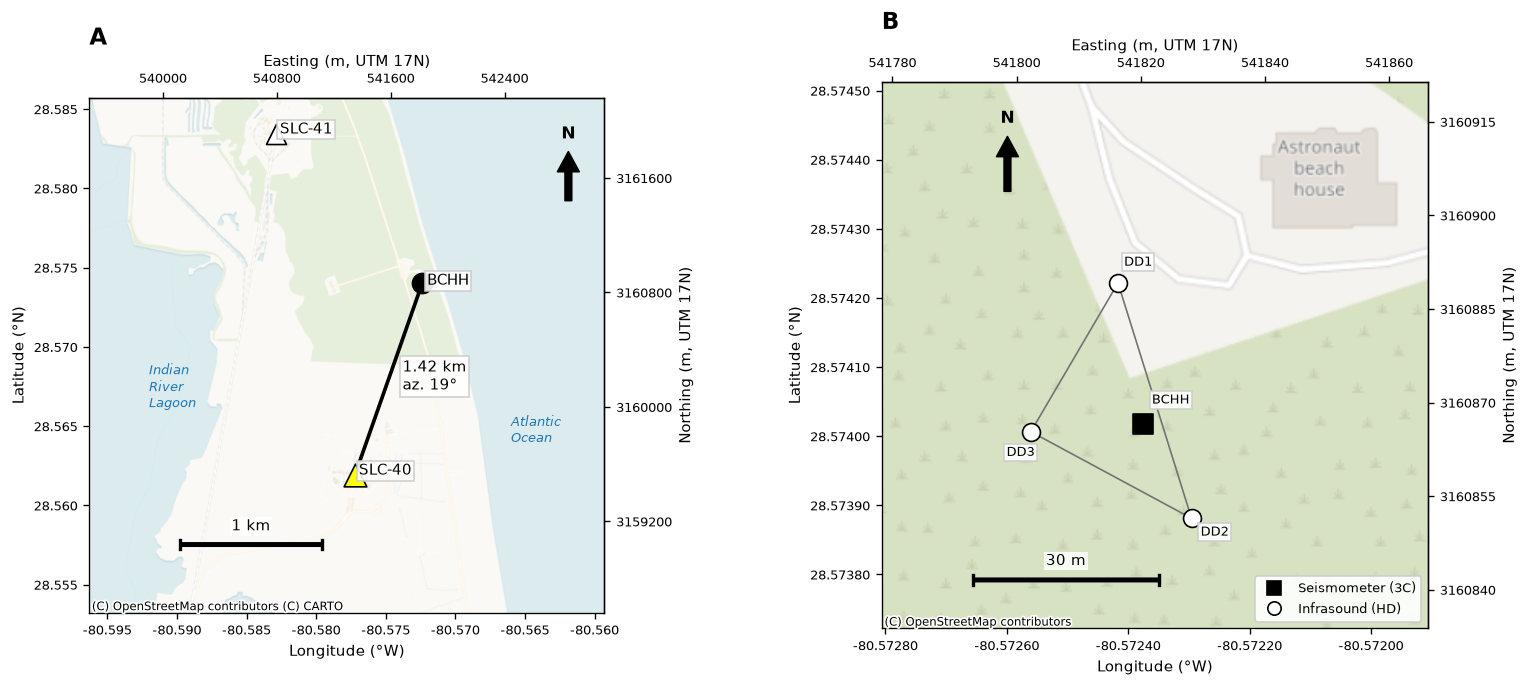

In [8]:

fig1, fig1_axes = make_figure1(
    slc40=FIGURE1_SLC40,
    slc41=FIGURE1_SLC41,
    bchh=FIGURE1_BCHH,
    bchh_sensors=FIGURE1_BCHH_SENSORS,
    geod=FIGURE1_GEOD,
    ll_to_utm=FIGURE1_LL_TO_UTM,
    utm_to_ll=FIGURE1_UTM_TO_LL,
)

plt.show()


In [9]:

figure1_output_paths = save_figure(
    fig=fig1,
    output_directory=OUTDIR,
    filename_stem=FIGURE1_STEM,
    extensions=("png", "pdf"),
    dpi=300,
)

for path in figure1_output_paths:
    print(path.resolve())


/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/14_paper_figures/fig01_slc40_bchh_location.png
/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/14_paper_figures/fig01_slc40_bchh_location.pdf


## 3. Receiver-specific acoustic propagation

BCHH geometry and the adopted effective acoustic speed come directly from
Notebooks 02, 03, and 08. Camera distances are computed from the canonical
SLC-40 coordinate and KML camera coordinates.


In [10]:
bchh_channels_df["effective_sound_speed_mps"] = (
    ADOPTED_ACOUSTIC_SPEED_MPS
)
bchh_channels_df["acoustic_travel_time_s"] = (
    bchh_channels_df["distance_m"]
    / ADOPTED_ACOUSTIC_SPEED_MPS
)
bchh_channels_df["shockwave_travel_time_s"] = (
    bchh_channels_df["acoustic_travel_time_s"]
)

if not camera_locations_df.empty:
    camera_locations_df["effective_sound_speed_mps"] = (
        ADOPTED_ACOUSTIC_SPEED_MPS
    )
    camera_locations_df["acoustic_travel_time_s"] = (
        camera_locations_df["distance_m"]
        / ADOPTED_ACOUSTIC_SPEED_MPS
    )
    camera_locations_df["shockwave_travel_time_s"] = (
        camera_locations_df["acoustic_travel_time_s"]
    )

SENSOR_ACOUSTIC_TRAVEL_TIMES_S = (
    bchh_channels_df
    .set_index("channel")["acoustic_travel_time_s"]
    .to_dict()
)
SENSOR_SHOCKWAVE_TRAVEL_TIMES_S = dict(
    SENSOR_ACOUSTIC_TRAVEL_TIMES_S
)
CAMERA_DISTANCES_M = (
    camera_locations_df.set_index("camera_id")["distance_m"].to_dict()
    if not camera_locations_df.empty else {}
)
CAMERA_ACOUSTIC_TRAVEL_TIMES_S = (
    camera_locations_df
    .set_index("camera_id")["acoustic_travel_time_s"]
    .to_dict()
    if not camera_locations_df.empty else {}
)
CAMERA_SHOCKWAVE_TRAVEL_TIMES_S = dict(
    CAMERA_ACOUSTIC_TRAVEL_TIMES_S
)

ACOUSTIC_SPEED_MPS = ADOPTED_ACOUSTIC_SPEED_MPS
WIND_SPEED_MPS = WindSpeedMps
SHOCK_SPEED_MPS = ADOPTED_ACOUSTIC_SPEED_MPS

display(bchh_channels_df[[
    "channel",
    "distance_m",
    "back_azimuth_to_slc40_deg",
    "effective_sound_speed_mps",
    "acoustic_travel_time_s",
]])
if not camera_locations_df.empty:
    display(camera_locations_df[[
        "camera_id",
        "name",
        "distance_m",
        "ray_azimuth_deg",
        "effective_sound_speed_mps",
        "acoustic_travel_time_s",
    ]])


,channel,distance_m,back_azimuth_to_slc40_deg,effective_sound_speed_mps,acoustic_travel_time_s
0,DD1,1439.963831,198.988027,351.960511,4.091265
1,DD2,1408.338457,199.943252,351.960511,4.001410
2,DD3,1412.854330,198.763913,351.960511,4.014241
3,DHE,1419.886511,199.438026,351.960511,4.034221
4,DHN,1419.886511,199.438026,351.960511,4.034221
5,DHZ,1419.886511,199.438026,351.960511,4.034221


,camera_id,name,distance_m,ray_azimuth_deg,effective_sound_speed_mps,acoustic_travel_time_s
0,youtube,FIREY,4254.532067,253.676701,351.960511,12.088095
1,pad_nw,PadNW,102.864227,319.923729,351.960511,0.292261
2,pad_west,PadW,134.745638,280.624512,351.960511,0.382843
3,pad_ne,PadNE,70.670423,44.172628,351.960511,0.200791
4,ucs3,UCS-3,1501.050255,13.445065,351.960511,4.264826


## 4. Load the canonical Notebook 02 waveform product

The figure notebook uses the response-corrected Stream with the adopted
moving-median correction already applied to DD1–DD3. Seismic D* channels are
unchanged by that correction.


In [11]:
st_corr = read(
    str(BASELINE_STREAM_FILE),
    format="PICKLE",
)
st_corr.trim(
    EXPLOSION_TIME - PRE_EVENT_SEC,
    EXPLOSION_TIME + POST_EVENT_SEC,
    pad=False,
)
st_corr.sort(keys=["station", "channel"])

loaded_channels = {
    trace.stats.channel
    for trace in st_corr
}
missing_channels = set(CHANNEL_ORDER) - loaded_channels
if missing_channels:
    raise KeyError(
        f"Notebook 02 baseline Stream lacks channels: {sorted(missing_channels)}"
    )

print(f"Loaded canonical waveform product:\n  {BASELINE_STREAM_FILE}")
print(st_corr)
for trace in st_corr:
    print(
        trace.id,
        trace.stats.starttime,
        trace.stats.endtime,
        trace.stats.sampling_rate,
        trace.stats.npts,
        trace.stats.get("units", "units not stored"),
    )

if CORRECTION_SUMMARY_FILE.exists():
    correction_summary_df = pd.read_csv(CORRECTION_SUMMARY_FILE)
    display(correction_summary_df)
else:
    correction_summary_df = None


Loaded canonical waveform product:
  /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/derived2/bchh_corrected_moving_median_baseline_removed.pkl
6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD1 2016-09-01T13:04:12.080000Z 2016-09-01T13:37:12.080000Z 250.0 495001 Pa
1R.BCHH.10.DD2 2016-09-01T13:04:12.080000Z 

,seed_id,network,station,location,channel,latitude,longitude,elevation_m,depth_m,azimuth_deg,...,raw_counts_rms,corrected_npts,corrected_finite_npts,corrected_minimum,corrected_maximum,corrected_peak_absolute,corrected_mean,corrected_median,corrected_standard_deviation,corrected_rms
0,1R.BCHH.10.DD1,1R,BCHH,10,DD1,28.574222,-80.572417,0.0,0.0,0.0,...,371942.533590,495001,495001,-253.017930,1349.141452,1349.141452,5.782297e-03,-4.131989e-01,33.066901,33.066901
1,1R.BCHH.10.DD2,1R,BCHH,10,DD2,28.573881,-80.572296,0.0,0.0,90.0,...,1723.056904,495001,495001,-219.103736,1557.411627,1557.411627,4.231537e-03,-4.250432e-02,7.850680,7.850681
2,1R.BCHH.10.DD3,1R,BCHH,10,DD3,28.574006,-80.572560,0.0,0.0,0.0,...,21436.222390,495001,495001,-222.554264,1434.860925,1434.860925,2.330593e-03,1.222732e+00,13.326245,13.326245
3,1R.BCHH.10.DHE,1R,BCHH,10,DHE,28.574017,-80.572376,0.0,0.0,90.0,...,4292.714630,495001,495001,-0.001094,0.001004,0.001094,1.701909e-12,-1.189176e-09,0.000013,0.000013
4,1R.BCHH.10.DHN,1R,BCHH,10,DHN,28.574017,-80.572376,0.0,0.0,0.0,...,6546.846691,495001,495001,-0.002207,0.001867,0.002207,-3.848072e-12,1.329465e-11,0.000022,0.000022
5,1R.BCHH.10.DHZ,1R,BCHH,10,DHZ,28.574017,-80.572376,0.0,0.0,0.0,...,13988.725742,495001,495001,-0.002876,0.002173,0.002876,-9.315448e-15,-2.071039e-09,0.000033,0.000033


## 5. Channel-type helpers

Instrument-response removal has already been completed. These helpers are retained only because the plotting and display-preprocessing functions use them to apply channel-specific filters and labels.


In [12]:
def is_seismic_channel(channel: str) -> bool:
    """Return True for the BCHH high-gain seismic channels."""
    channel = channel.upper()
    return len(channel) >= 2 and channel[1] in {"H", "L"}


def is_infrasound_channel(channel: str) -> bool:
    """Return True for the BCHH pressure channels."""
    channel = channel.upper()
    return len(channel) >= 2 and channel[1] == "D"


def is_audio_channel(channel: str) -> bool:
    """Return True for imported video/audio waveform channels."""
    return channel.upper() in {"AUD", "AUDIO"}


## 6. Generic plotting and preprocessing utilities

ZEROPHASE filters can still introduce phase/group delay, so pick timing should be checked against minimally processed traces as well.


In [13]:
def trace_time_array_datetime64(tr):
    """Return matplotlib date numbers for all samples in a trace."""
    t0 = tr.stats.starttime.datetime
    sr = float(tr.stats.sampling_rate)
    seconds = np.arange(tr.stats.npts, dtype=float) / sr
    return mdates.date2num(t0) + seconds / 86400.0


def robust_scale(data, percentile=99.3):
    """Robust absolute-amplitude scale for display."""
    x = np.asarray(data, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    s = np.percentile(np.abs(x), percentile)
    return s if np.isfinite(s) and s > 0 else 1.0


def select_channels_in_order(st: Stream, channel_order) -> Stream:
    """Return a stream containing the first matching trace for each requested channel."""
    selected = Stream()
    for ch in channel_order:
        matches = st.select(channel=ch)
        if len(matches) == 0:
            matches = Stream([tr for tr in st if tr.stats.channel.upper() == ch.upper()])
        if len(matches):
            selected += matches[0].copy()
        else:
            warnings.warn(f'No trace found for channel {ch}')
    return selected


def preprocess_display_stream(
    st: Stream,
    starttime: UTCDateTime | None = None,
    endtime: UTCDateTime | None = None,
    infra_filter: dict | None = None,
    seis_filter: dict | None = None,
) -> Stream:
    """Trim, detrend, taper, and filter a stream for display only."""
    out = Stream()
    for tr0 in st:
        tr = tr0.copy()
        if starttime is not None and endtime is not None:
            tr.trim(starttime, endtime, pad=True, fill_value=0.0)
        tr.detrend('demean')
        tr.detrend('linear')
        tr.taper(max_percentage=0.005)

        ch = tr.stats.channel.upper()
        if is_infrasound_channel(ch) and infra_filter is not None:
            tr.filter(**infra_filter)
        elif is_seismic_channel(ch) and seis_filter is not None:
            tr.filter(**seis_filter)

        out += tr
    return out


def acoustic_or_seismic_delay_s(
    channel: str,
    distance_m: float,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float,
    hh_use_direct_seismic_speed: bool,
) -> float:
    """Return the travel-time correction for one physical BCHH channel."""
    ch = channel.upper()
    if is_audio_channel(ch):
        return 0.0
    if is_infrasound_channel(ch):
        return distance_m / acoustic_speed_mps
    if is_seismic_channel(ch):
        speed = direct_seismic_speed_mps if hh_use_direct_seismic_speed else acoustic_speed_mps
        return distance_m / speed
    return 0.0


def reduce_stream_to_source_time_physical(
    st: Stream,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float,
    hh_use_direct_seismic_speed: bool,
    audio_delay_s: float,
) -> Stream:
    """Shift each trace earlier by its assumed source-to-receiver travel time."""
    st_red = st.copy()

    for tr in st_red:
        ch = tr.stats.channel.upper()

        if is_audio_channel(ch):
            delay_s = audio_delay_s
        elif ch in sensor_distances_m:
            delay_s = acoustic_or_seismic_delay_s(
                ch,
                distance_m=sensor_distances_m[ch],
                acoustic_speed_mps=acoustic_speed_mps,
                direct_seismic_speed_mps=direct_seismic_speed_mps,
                hh_use_direct_seismic_speed=hh_use_direct_seismic_speed,
            )
        else:
            delay_s = 0.0

        print(f"Reducing {tr.id} by {delay_s:.4f} s")
        tr.stats.starttime -= delay_s
        tr.stats.processing = tr.stats.get("processing", [])
        tr.stats.processing.append(f"reduced_time_shift_minus_{delay_s:.4f}_s")

    return st_red


def zerophase_tag(zerophase: bool) -> str:
    """Short filename tag for the filter phase convention."""
    return "zp_true" if bool(zerophase) else "zp_false"


def add_zerophase_tag(outfile_base: Path, zerophase: bool) -> Path:
    """Append the zerophase convention to an output filename stem."""
    return outfile_base.with_name(f"{outfile_base.name}_{zerophase_tag(zerophase)}")


def bandpass_filter_dict(freqmin, freqmax, corners=4, zerophase=False):
    """Build an ObsPy bandpass filter dictionary with explicit zerophase."""
    return {
        "type": "bandpass",
        "freqmin": float(freqmin),
        "freqmax": float(freqmax),
        "corners": int(corners),
        "zerophase": bool(zerophase),
    }


## 7. Build the response-corrected display stream


In [14]:
def build_overview_stream(
    st: Stream,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    zerophase: bool,
    infra_freqmin: float = 0.5,
    infra_freqmax: float = 25.0,
    seis_freqmin: float = 0.5,
    seis_freqmax: float = 25.0,
    corners: int = 4,
) -> Stream:
    """Build the filtered 30-minute display stream for one zerophase setting."""
    overview_infra_filter = bandpass_filter_dict(
        freqmin=infra_freqmin,
        freqmax=infra_freqmax,
        corners=corners,
        zerophase=zerophase,
    )
    overview_seis_filter = bandpass_filter_dict(
        freqmin=seis_freqmin,
        freqmax=seis_freqmax,
        corners=corners,
        zerophase=zerophase,
    )

    return preprocess_display_stream(
        st,
        starttime=plot_start,
        endtime=plot_end,
        infra_filter=overview_infra_filter,
        seis_filter=overview_seis_filter,
    )


st_ordered = select_channels_in_order(st_corr, CHANNEL_ORDER)
st_overview = build_overview_stream(
    st=st_ordered,
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    zerophase=ZEROPHASE,
)

print(f"Overview stream built with ZEROPHASE={ZEROPHASE}")
print(st_overview)


Overview stream built with ZEROPHASE=False
6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples


## 8. Figure 2: 30-minute overview figure


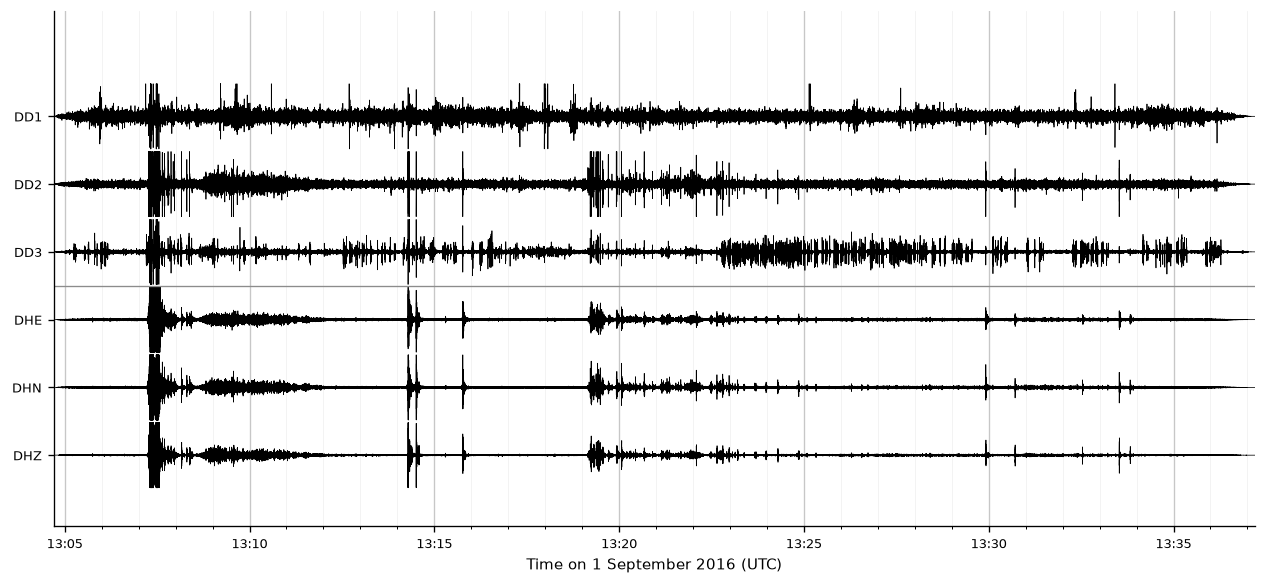

In [15]:
def add_time_bar(ax, t0, t1, y, text, above=True, lw=1.4, fontsize=9):
    """Draw a bracket-style time interval annotation."""
    x0 = mdates.date2num(t0.datetime)
    x1 = mdates.date2num(t1.datetime)

    ax.plot([x0, x1], [y, y], color="black", lw=lw, clip_on=False, zorder=20)
    tick = 0.08
    ax.plot([x0, x0], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)
    ax.plot([x1, x1], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)

    dy = 0.12 if above else -0.12
    va = "bottom" if above else "top"
    ax.text(
        (x0 + x1) / 2,
        y + dy,
        text,
        ha="center",
        va=va,
        fontsize=fontsize,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.0),
        clip_on=False,
        zorder=25,
    )


def make_overview_figure(
    st: Stream,
    outfile_base: Path,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    phases: list,
    explosion_time: UTCDateTime,
    tremor_start: UTCDateTime | None = None,
    tremor_end: UTCDateTime | None = None,
    normalize_by_group: bool = False,
    clip: float = 3.0,
    trace_gain: float = 0.15,
):
    """Make the 30-minute BCHH overview figure."""
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.8))
    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []

    infra_scales = [robust_scale(tr.data) for tr in st if is_infrasound_channel(tr.stats.channel)]
    seis_scales = [robust_scale(tr.data) for tr in st if is_seismic_channel(tr.stats.channel)]
    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        t = trace_time_array_datetime64(tr)
        data = np.nan_to_num(tr.data.astype(float), nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.3)

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, '-', color='black', lw=0.45, rasterized=True)
        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-1.05, n + 0.55)
    ax.set_xlim(mdates.date2num(plot_start.datetime), mdates.date2num(plot_end.datetime))

    ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 5)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.grid(axis='x', which='major', color='0.78', lw=0.8)
    ax.grid(axis='x', which='minor', color='0.93', lw=0.4)
    ax.set_xlabel('Time on 1 September 2016 (UTC)')

    # Separator between infrasound and seismic channels for default 3+3 order.
    if n >= 6:
        ax.axhline(2.5, color='0.55', lw=0.8)

    phase_y = n + 0.18
    for name, t0, t1 in phases:
        if name.strip().lower() == 'phase i':
            t0 = explosion_time
        if t1 < plot_start or t0 > plot_end:
            continue
        add_time_bar(ax, max(t0, plot_start), min(t1, plot_end), phase_y, name, above=True)

    if tremor_start is not None and tremor_end is not None:
        if tremor_end >= plot_start and tremor_start <= plot_end:
            add_time_bar(
                ax,
                max(tremor_start, plot_start),
                min(tremor_end, plot_end),
                y=-0.4,
                text='tremor',
                above=False,
                lw=1.2,
            )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.88, bottom=0.14)

    for ext in ['png', 'pdf']:
        fig.savefig(outfile_base.with_suffix(f'.{ext}'), dpi=300, bbox_inches='tight', pad_inches=0.04)

    return fig, ax


overview_outfile = add_zerophase_tag(
    OUTDIR / 'fig03_bchh_30min_overview',
    ZEROPHASE,
)

fig, ax = make_overview_figure(
    st_overview,
    overview_outfile,
    PLOT_START,
    PLOT_END,
    phases=PHASES,
    explosion_time=EXPLOSION_TIME,
    tremor_start=TREMOR_START,
    tremor_end=TREMOR_END,
    normalize_by_group=False,
    clip=3.0,
    trace_gain=0.16,
)
plt.show()


## 9. Quick amplitude diagnostic

Use this to sanity-check response-corrected amplitudes before using the figures in the manuscript.


In [16]:
rows = []
for tr in st_ordered:
    x = np.asarray(tr.data, dtype=float)
    rows.append({
        'id': tr.id,
        'channel': tr.stats.channel,
        'units': getattr(tr.stats, 'units', ''),
        'sampling_rate': tr.stats.sampling_rate,
        'min': float(np.nanmin(x)),
        'max': float(np.nanmax(x)),
        'p99_abs': float(np.nanpercentile(np.abs(x), 99)),
        'p99_9_abs': float(np.nanpercentile(np.abs(x), 99.9)),
    })

try:
    import pandas as pd
    display(pd.DataFrame(rows))
except Exception:
    for r in rows:
        print(r)


,id,channel,units,sampling_rate,min,max,p99_abs,p99_9_abs
0,1R.BCHH.10.DD1,DD1,Pa,250.0,-138.805934,1301.957255,29.460085,83.426579
1,1R.BCHH.10.DD2,DD2,Pa,250.0,-163.344631,1507.523187,6.779089,35.129625
2,1R.BCHH.10.DD3,DD3,Pa,250.0,-163.765403,1385.597666,32.291717,57.069255
3,1R.BCHH.10.DHE,DHE,m/s,250.0,-0.001094,0.001004,0.000033,0.000188
4,1R.BCHH.10.DHN,DHN,m/s,250.0,-0.002207,0.001867,0.000043,0.000295
5,1R.BCHH.10.DHZ,DHZ,m/s,250.0,-0.002876,0.002173,0.000057,0.000476


## Peak and reduced-pressure measurements from Notebook 11

The authoritative numerical measurements are loaded from
`key_event_pressure_measurements.csv`. This notebook only displays them and
uses the corresponding pipeline event times to define waveform panels.


In [17]:
from collections.abc import Mapping

# Surveyed source-to-sensor distances from SLC-40.
# Update these values if the final geometry table changes.
BCHH_INFRASOUND_DISTANCES_M = {
    "DD1": 1442.2,
    "DD2": 1410.2,
    "DD3": 1414.8,
}


def _channel_code(trace) -> str:
    """Return the final channel code, e.g. DD1, from an ObsPy Trace."""
    return str(trace.stats.channel).upper()


def measure_reduced_pressures(
    st_event: Stream,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    #highpass: bool = False,
) -> pd.DataFrame:
    """
    Measure observed and reduced pressures from a short calibrated event stream.

    Parameters
    ----------
    st_event
        ObsPy Stream containing calibrated infrasound traces in Pa. The stream
        should already be trimmed to the desired event window.
    sensor_distances_m
        Mapping from channel code, such as ``DD1``, to source-to-sensor
        distance in metres.
    reference_distance_m
        Distance to which pressures are reduced. The default is 1000 m.
    event_name
        Optional event label added to the output table.

    Returns
    -------
    pandas.DataFrame
        One row per infrasound channel, containing observed and reduced
        positive, negative, negative-magnitude, and peak-to-peak pressures.

    Notes
    -----
    Reduced pressure is calculated assuming spherical spreading:

        p_reduced = p_observed * distance / reference_distance

    The negative pressure retains its sign. ``negative_magnitude_pa`` is also
    included for convenient comparison with the positive peak.
    """
    if reference_distance_m <= 0:
        raise ValueError("reference_distance_m must be positive.")

    if len(st_event) == 0:
        raise ValueError("st_event contains no traces.")

    rows: list[dict[str, Any]] = []
    
    st_event2 = st_event.copy()
    #if highpass:
    #    st_event2.filter('highpass', freq=5, corners=2)
    for tr in st_event2:
        channel = _channel_code(tr)

        if channel not in sensor_distances_m:
            continue

        distance_m = float(sensor_distances_m[channel])
        if not np.isfinite(distance_m) or distance_m <= 0:
            raise ValueError(
                f"Invalid source distance for {channel}: {distance_m}"
            )

        data = np.asarray(tr.data, dtype=float)
        data = data[np.isfinite(data)]

        if data.size == 0:
            raise ValueError(f"{tr.id} contains no finite samples.")

        positive_peak_pa = float(np.max(data))
        negative_peak_pa = float(np.min(data))
        negative_magnitude_pa = abs(negative_peak_pa)
        peak_to_peak_pa = positive_peak_pa - negative_peak_pa

        reduction_factor = distance_m / reference_distance_m

        rows.append(
            {
                "event": event_name,
                "id": tr.id,
                "channel": channel,
                "starttime": tr.stats.starttime,
                "endtime": tr.stats.endtime,
                "sampling_rate_hz": float(tr.stats.sampling_rate),
                "npts": int(tr.stats.npts),
                "distance_m": distance_m,
                "reference_distance_m": float(reference_distance_m),
                "reduction_factor": reduction_factor,
                "positive_peak_pa": positive_peak_pa,
                "negative_peak_pa": negative_peak_pa,
                "negative_magnitude_pa": negative_magnitude_pa,
                "peak_to_peak_pa": peak_to_peak_pa,
                "positive_reduced_pa": positive_peak_pa * reduction_factor,
                "negative_reduced_pa": negative_peak_pa * reduction_factor,
                "negative_magnitude_reduced_pa": (
                    negative_magnitude_pa * reduction_factor
                ),
                "peak_to_peak_reduced_pa": peak_to_peak_pa * reduction_factor,
            }
        )

    if not rows:
        available = sorted({_channel_code(tr) for tr in st_event})
        expected = sorted(sensor_distances_m)
        raise ValueError(
            "No traces matched the distance dictionary. "
            f"Available channels: {available}; expected channels: {expected}"
        )

    result = pd.DataFrame(rows).sort_values("channel").reset_index(drop=True)

    # Add robust three-sensor summaries as a separate final row.
    numeric_columns = [
        "distance_m",
        "reduction_factor",
        "positive_peak_pa",
        "negative_peak_pa",
        "negative_magnitude_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_peak_pa",
        "negative_reduced_pa",
        "negative_magnitude_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    summary = {
        "event": event_name,
        "id": "ARRAY_MEDIAN",
        "channel": "MEDIAN",
        "starttime": result["starttime"].min(),
        "endtime": result["endtime"].max(),
        "sampling_rate_hz": result["sampling_rate_hz"].median(),
        "npts": np.nan,
        "reference_distance_m": float(reference_distance_m),
    }

    for column in dict.fromkeys(numeric_columns):
        summary[column] = result[column].median()

    result = pd.concat(
        [result, pd.DataFrame([summary])],
        ignore_index=True,
    )

    return result


def measure_reduced_pressures_in_window(
    st: Stream,
    starttime: UTCDateTime | str,
    endtime: UTCDateTime | str,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    nearest_sample: bool = True,
    #highpass: bool = False,
) -> tuple[Stream, pd.DataFrame]:
    """
    Trim a calibrated stream to an event window and measure reduced pressures.

    Returns both the trimmed event stream and the measurement table.
    """
    t0 = UTCDateTime(starttime)
    t1 = UTCDateTime(endtime)

    if t1 <= t0:
        raise ValueError(f"endtime must follow starttime: {t0} to {t1}")

    st_event = st.copy()
    st_event.trim(
        starttime=t0,
        endtime=t1,
        nearest_sample=nearest_sample,
        pad=False,
    )

    '''
    # Retain only infrasound channels represented in the distance dictionary.
    st_event = Stream(
        traces=[
            tr for tr in st_event
            if _channel_code(tr) in sensor_distances_m
        ]
    )
    '''

    measurements = measure_reduced_pressures(
        st_event.select(channel='HD*'),
        sensor_distances_m,
        reference_distance_m=reference_distance_m,
        event_name=event_name,
        #highpass=highpass,
    )

    return st_event, measurements


def pressure_results_for_paper(
    measurements: pd.DataFrame,
) -> pd.DataFrame:
    """Return a compact, publication-oriented view of the measurements."""
    columns = [
        "event",
        "channel",
        "distance_m",
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    output = measurements.loc[:, columns].copy()

    pressure_columns = [
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    output["distance_m"] = output["distance_m"].round(1)
    output[pressure_columns] = output[pressure_columns].round(1)

    return output

In [18]:
print(st_corr)

6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples


In [19]:
if key_event_pressures.empty:
    warnings.warn(
        f"Notebook 11 pressure measurements not found: "
        f"{KEY_EVENT_PRESSURES_FILE}"
    )
else:
    print("Authoritative Notebook 11 key-event measurements:")
    display(key_event_pressures)

if key_event_windows.empty:
    warnings.warn(
        f"Notebook 11 measurement windows not found: "
        f"{KEY_EVENT_WINDOWS_FILE}"
    )
else:
    print("Authoritative Notebook 11 measurement windows:")
    display(key_event_windows)


Authoritative Notebook 11 key-event measurements:


,event,id,channel,distance_m,baseline_pa,positive_peak_time_s,negative_peak_time_s,positive_peak_pa,negative_peak_pa,peak_to_peak_pa,positive_reduced_pa,negative_reduced_pa,peak_to_peak_reduced_pa
0,Initial second-stage failure,1R.BCHH.10.DD1,DD1,1439.963831,9.656469,1.024,0.868,30.387556,-72.234297,102.621853,43.756981,-104.014775,147.771756
1,Initial second-stage failure,1R.BCHH.10.DD2,DD2,1408.338457,0.122600,0.936,1.184,51.720138,-25.389659,77.109797,72.839459,-35.757233,108.596692
2,Initial second-stage failure,1R.BCHH.10.DD3,DD3,1412.854330,0.026519,1.300,1.196,38.845461,-21.231573,60.077033,54.882977,-29.997119,84.880097
3,Initial second-stage failure,ARRAY_MEDIAN,MEDIAN,1412.854330,0.122600,NaN,NaN,38.845461,-25.389659,77.109797,54.882977,-35.757233,108.596692
4,Principal explosion,1R.BCHH.10.DD1,DD1,1439.963831,-10.588649,1.532,1.968,1312.545904,-127.375631,1439.921535,1890.018627,-183.416302,2073.434929
5,Principal explosion,1R.BCHH.10.DD2,DD2,1408.338457,-5.176922,1.444,1.756,1512.700109,-158.167708,1670.867817,2130.393737,-222.753666,2353.147403
6,Principal explosion,1R.BCHH.10.DD3,DD3,1412.854330,-7.301694,1.456,1.896,1392.899360,-156.463709,1549.363069,1967.963893,-221.060429,2189.024322
7,Principal explosion,ARRAY_MEDIAN,MEDIAN,1412.854330,-7.301694,NaN,NaN,1392.899360,-156.463709,1549.363069,1967.963893,-221.060429,2189.024322
8,Capsule pulse 1,1R.BCHH.10.DD1,DD1,1439.963831,10.448821,0.212,0.256,238.726189,-115.115268,353.841457,343.757078,-165.761822,509.518900
9,Capsule pulse 1,1R.BCHH.10.DD2,DD2,1408.338457,-3.893888,0.124,0.168,279.856243,-114.613499,394.469742,394.132309,-161.414599,555.546908


Authoritative Notebook 11 measurement windows:


,event,window_start_utc,window_end_utc,window_start_epoch_s,window_end_epoch_s,window_duration_s,baseline_start_s,baseline_end_s,signal_start_s,signal_end_s,reference_distance_m,waveform_product,geometry_product
0,Initial second-stage failure,2016-09-01T13:07:15,2016-09-01T13:07:17,1.472735e+09,1.472735e+09,2.00,0.1,0.80,0.85,1.40,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
1,Principal explosion,2016-09-01T13:07:18,2016-09-01T13:07:21,1.472735e+09,1.472735e+09,3.00,0.1,0.75,0.75,2.50,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
2,Capsule pulse 1,2016-09-01T13:07:28.300000,2016-09-01T13:07:28.750000,1.472735e+09,1.472735e+09,0.45,0.0,0.12,0.12,0.45,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
3,Capsule pulse 2,2016-09-01T13:07:28.850000,2016-09-01T13:07:29.250000,1.472735e+09,1.472735e+09,0.40,0.0,0.10,0.10,0.40,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...


In [20]:

from collections.abc import Mapping

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
from obspy import Stream, UTCDateTime


def plot_main_explosion(
    st_event: Stream,
    *,
    reference_time: UTCDateTime | str,
    pressure_results=None,
    title: str = "Principal explosion",
    seismic_channels: tuple[str, ...] = ("DHZ", "DHN", "DHE"),
    infrasound_channels: tuple[str, ...] = ("DD1", "DD2", "DD3"),
    seismic_labels: Mapping[str, str] | None = None,
    infrasound_labels: Mapping[str, str] | None = None,
    figsize: tuple[float, float] = (11.5, 6.8),
    outfile=None,
    add_measurements=False,
):
    """
    Plot the principal explosion as grouped seismic and infrasound panels.

    Parameters
    ----------
    st_event
        Response-corrected event stream. Seismic traces must be in m/s and
        infrasound traces in Pa.
    reference_time
        Time used for the relative x-axis.
    pressure_results
        Optional DataFrame returned by the pressure measurement function.
        When supplied, positive and negative pressure extrema are marked.
    title
        Figure title.
    outfile
        Optional output path. If supplied, the figure is saved.
    """
    reference_time = UTCDateTime(reference_time)

    if seismic_labels is None:
        seismic_labels = {
            "DHZ": "Vertical",
            "DHN": "North",
            "DHE": "East",
        }

    if infrasound_labels is None:
        infrasound_labels = {
            "DD1": "DD1",
            "DD2": "DD2",
            "DD3": "DD3",
        }

    seismic_traces = []
    for channel in seismic_channels:
        matches = st_event.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(
                f"Expected one {channel} trace, found {len(matches)}."
            )
        seismic_traces.append(matches[0])

    pressure_traces = []
    for channel in infrasound_channels:
        matches = st_event.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(
                f"Expected one {channel} trace, found {len(matches)}."
            )
        pressure_traces.append(matches[0])

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    grid = fig.add_gridspec(
        nrows=3,
        ncols=2,
        width_ratios=(1.0, 1.25),
        wspace=0.08,
        hspace=0.05,
    )

    seismic_axes = [
        fig.add_subplot(grid[row, 0])
        for row in range(3)
    ]

    pressure_axes = [
        fig.add_subplot(grid[row, 1])
        for row in range(3)
    ]

    # Determine common limits within each instrument group.
    seismic_limit = max(
        np.nanmax(np.abs(np.asarray(tr.data, dtype=float)))
        for tr in seismic_traces
    )
    seismic_limit *= 1.08

    pressure_min = min(
        np.nanmin(np.asarray(tr.data, dtype=float))
        for tr in pressure_traces
    )
    pressure_max = max(
        np.nanmax(np.asarray(tr.data, dtype=float))
        for tr in pressure_traces
    )

    pressure_padding = 0.05 * (pressure_max - pressure_min)
    pressure_ylim = (
        pressure_min - pressure_padding,
        pressure_max + pressure_padding,
    )

    # Plot seismic components.
    for index, (ax, tr) in enumerate(
        zip(seismic_axes, seismic_traces)
    ):
        channel = tr.stats.channel
        time_s = tr.times(
            reftime=reference_time
        )
        data = np.asarray(tr.data, dtype=float)

        ax.plot(time_s, data, linewidth=0.9)
        ax.axhline(0.0, linewidth=0.5, alpha=0.5)

        ax.set_ylim(-seismic_limit, seismic_limit)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

        ax.text(
            0.02,
            0.86,
            seismic_labels.get(channel, channel),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        if index < 2:
            ax.tick_params(labelbottom=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Plot infrasound channels.
    for index, (ax, tr) in enumerate(
        zip(pressure_axes, pressure_traces)
    ):
        channel = tr.stats.channel
        time_s = tr.times(
            reftime=reference_time
        )
        data = np.asarray(tr.data, dtype=float)

        ax.plot(time_s, data, linewidth=1.0)
        ax.axhline(0.0, linewidth=0.5, alpha=0.5)
        ax.set_ylim(*pressure_ylim)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

        ax.text(
            0.02,
            0.86,
            infrasound_labels.get(channel, channel),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        # Mark positive and negative extrema.
        positive_index = int(np.nanargmax(data))
        negative_index = int(np.nanargmin(data))

        positive_time = time_s[positive_index]
        negative_time = time_s[negative_index]

        positive_value = data[positive_index]
        negative_value = data[negative_index]

        ax.scatter(
            positive_time,
            positive_value,
            s=24,
            zorder=4,
        )
        ax.scatter(
            negative_time,
            negative_value,
            s=24,
            zorder=4,
        )

        ax.annotate(
            f"{positive_value:.0f} Pa",
            xy=(positive_time, positive_value),
            xytext=(5, -16),
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="top",
        )

        ax.annotate(
            f"{negative_value:.0f} Pa",
            xy=(negative_time, negative_value),
            xytext=(5, 7),
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="bottom",
        )

        if index < 2:
            ax.tick_params(labelbottom=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Shared x limits.
    all_traces = seismic_traces + pressure_traces

    xmin = min(
        tr.stats.starttime - reference_time
        for tr in all_traces
    )
    xmax = max(
        tr.stats.endtime - reference_time
        for tr in all_traces
    )

    for ax in seismic_axes + pressure_axes:
        ax.set_xlim(xmin, xmax)
        ax.grid(axis="x", linewidth=0.4, alpha=0.3)

    seismic_axes[0].set_title(
        "Ground velocity",
        fontsize=11,
        fontweight="bold",
    )
    pressure_axes[0].set_title(
        "Acoustic pressure",
        fontsize=11,
        fontweight="bold",
    )

    seismic_axes[1].set_ylabel(
        "Ground velocity (m s$^{-1}$)"
    )
    pressure_axes[1].set_ylabel(
        "Pressure (Pa)"
    )

    seismic_axes[-1].set_xlabel(
        f"Time relative to {reference_time.strftime('%H:%M:%S.%f')[:-3]} UTC (s)"
    )
    pressure_axes[-1].set_xlabel(
        f"Time relative to {reference_time.strftime('%H:%M:%S.%f')[:-3]} UTC (s)"
    )

    fig.suptitle(
        title,
        fontsize=13,
        fontweight="bold",
    )

    if pressure_results is not None and add_measurements:
        sensor_rows = pressure_results[
            pressure_results["channel"].isin(infrasound_channels)
        ]

        if len(sensor_rows) > 0:
            median_positive = sensor_rows[
                "positive_peak_pa"
            ].median()

            median_reduced = sensor_rows[
                "positive_reduced_pa"
            ].median()

            fig.text(
                0.995,
                0.91,
                (
                    f"Median positive peak: {median_positive / 1000:.2f} kPa; "
                    f"median reduced pressure at 1 km: "
                    f"{median_reduced / 1000:.2f} kPa"
                ),
                ha="right",
                va="bottom",
                fontsize=8.5,
            )

    if outfile is not None:
        fig.savefig(
            outfile,
            dpi=300,
            bbox_inches="tight",
        )

    return fig, {
        "seismic": seismic_axes,
        "infrasound": pressure_axes,
    }

In [21]:

from collections.abc import Mapping

import numpy as np
import pandas as pd
from obspy import Stream, UTCDateTime


def measure_reduced_pressures(
    st_event: Stream,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    baseline_start_s: float = 0.0,
    baseline_end_s: float = 0.75,
    signal_start_s: float | None = None,
    signal_end_s: float | None = None,
) -> pd.DataFrame:
    """
    Measure locally baseline-corrected pressure amplitudes.

    Times are specified in seconds relative to the start of each trace in
    ``st_event``.

    Parameters
    ----------
    st_event
        Calibrated infrasound event stream in Pa.
    sensor_distances_m
        Mapping from channel code to source-to-sensor distance in metres.
    reference_distance_m
        Reference distance for reduced pressure.
    event_name
        Optional event label.
    baseline_start_s, baseline_end_s
        Quiet pre-event interval used to estimate the local pressure baseline.
    signal_start_s, signal_end_s
        Interval over which extrema are measured. If omitted, measurement begins
        at ``baseline_end_s`` and continues to the end of the trace.
    """
    if reference_distance_m <= 0:
        raise ValueError("reference_distance_m must be positive.")

    if baseline_end_s <= baseline_start_s:
        raise ValueError("baseline_end_s must be greater than baseline_start_s.")

    if signal_start_s is None:
        signal_start_s = baseline_end_s

    rows = []

    for tr in st_event:
        channel = str(tr.stats.channel).upper()

        if channel not in sensor_distances_m:
            continue

        data = np.asarray(tr.data, dtype=float)
        sampling_rate = float(tr.stats.sampling_rate)
        times = tr.times()

        baseline_mask = (
            (times >= baseline_start_s)
            & (times < baseline_end_s)
            & np.isfinite(data)
        )

        if not np.any(baseline_mask):
            raise ValueError(
                f"No baseline samples found for {tr.id} in "
                f"{baseline_start_s:.3f}–{baseline_end_s:.3f} s."
            )

        baseline_pa = float(np.nanmedian(data[baseline_mask]))
        corrected_data = data - baseline_pa

        signal_mask = (
            (times >= signal_start_s)
            & np.isfinite(corrected_data)
        )

        if signal_end_s is not None:
            signal_mask &= times <= signal_end_s

        if not np.any(signal_mask):
            raise ValueError(
                f"No signal samples found for {tr.id} in the requested window."
            )

        signal_data = corrected_data[signal_mask]
        signal_times = times[signal_mask]

        positive_index = int(np.nanargmax(signal_data))
        negative_index = int(np.nanargmin(signal_data))

        positive_peak_pa = float(signal_data[positive_index])
        negative_peak_pa = float(signal_data[negative_index])
        peak_to_peak_pa = positive_peak_pa - negative_peak_pa

        distance_m = float(sensor_distances_m[channel])
        reduction_factor = distance_m / reference_distance_m

        rows.append(
            {
                "event": event_name,
                "id": tr.id,
                "channel": channel,
                "distance_m": distance_m,
                "baseline_pa": baseline_pa,
                "positive_peak_time_s": float(signal_times[positive_index]),
                "negative_peak_time_s": float(signal_times[negative_index]),
                "positive_peak_pa": positive_peak_pa,
                "negative_peak_pa": negative_peak_pa,
                "peak_to_peak_pa": peak_to_peak_pa,
                "positive_reduced_pa": positive_peak_pa * reduction_factor,
                "negative_reduced_pa": negative_peak_pa * reduction_factor,
                "peak_to_peak_reduced_pa": peak_to_peak_pa * reduction_factor,
            }
        )

    if not rows:
        raise ValueError("No infrasound channels matched sensor_distances_m.")

    result = (
        pd.DataFrame(rows)
        .sort_values("channel")
        .reset_index(drop=True)
    )

    summary_columns = [
        "distance_m",
        "baseline_pa",
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    summary = {
        "event": event_name,
        "id": "ARRAY_MEDIAN",
        "channel": "MEDIAN",
        "positive_peak_time_s": np.nan,
        "negative_peak_time_s": np.nan,
    }

    for column in summary_columns:
        summary[column] = float(result[column].median())

    return pd.concat(
        [result, pd.DataFrame([summary])],
        ignore_index=True,
    )

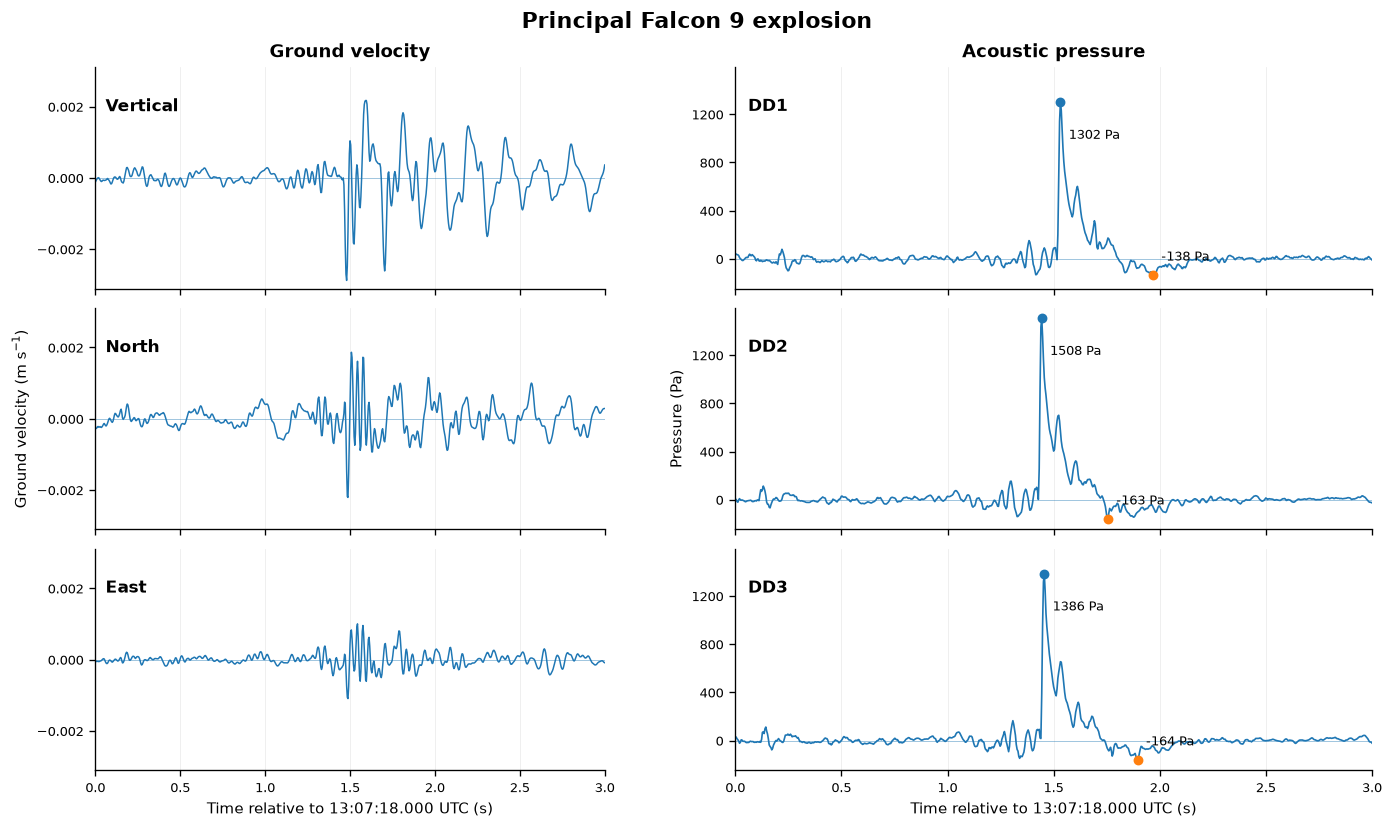

In [22]:
principal_window = key_event_window(r"principal")

MAIN_EXPLOSION_START = principal_window["start"]
MAIN_EXPLOSION_END = principal_window["end"]

st_main_explosion = st_corr.copy().trim(
    MAIN_EXPLOSION_START,
    MAIN_EXPLOSION_END,
)
main_explosion_pressures = key_event_pressures.loc[
    key_event_pressures["event"]
    .astype(str)
    .str.contains("principal", case=False, na=False)
].copy()

fig, axes = plot_main_explosion(
    st_main_explosion,
    reference_time=MAIN_EXPLOSION_START,
    pressure_results=main_explosion_pressures,
    title="Principal Falcon 9 explosion",
    outfile=OUTDIR / "principal_explosion_waveforms.png",
)


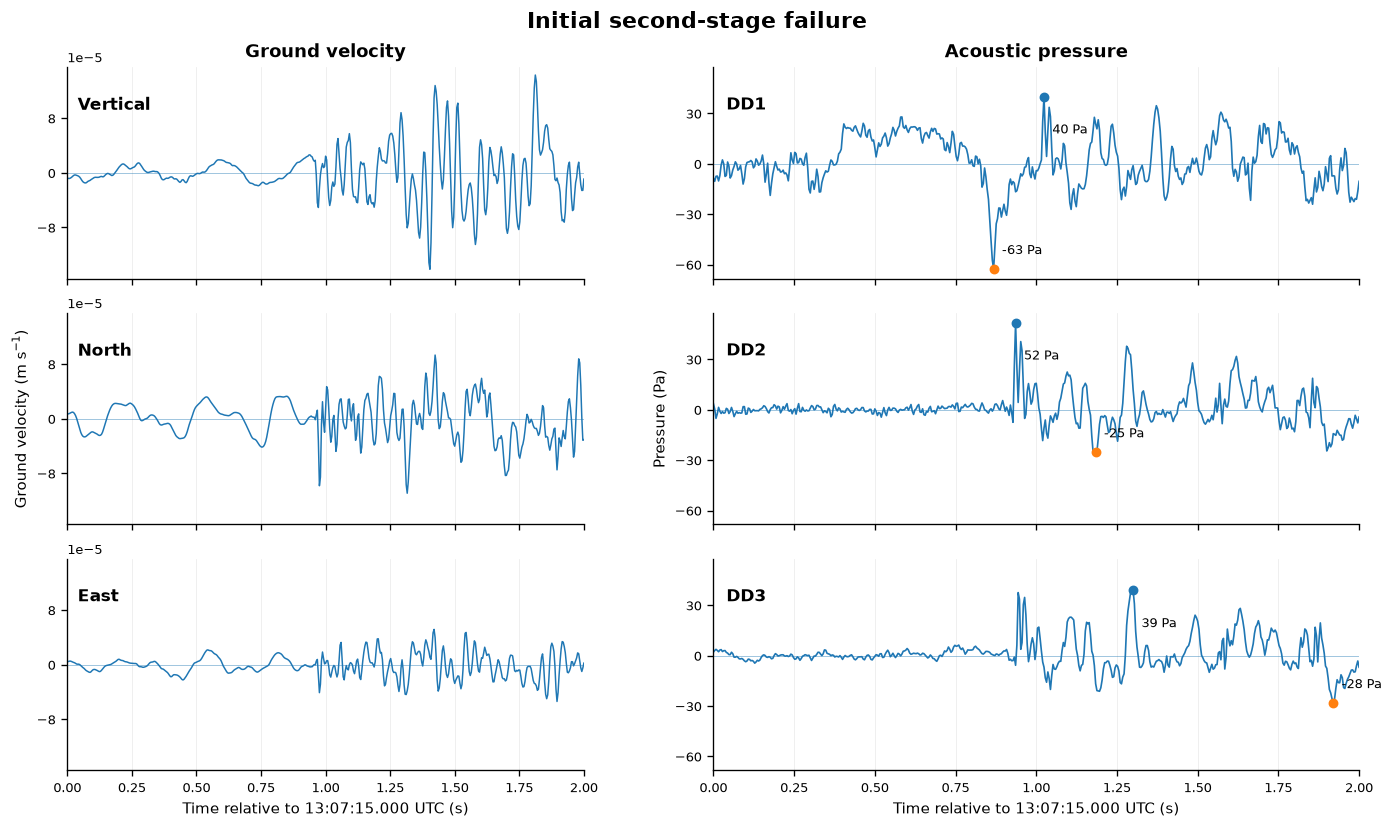

In [23]:
second_stage_window = key_event_window(
    r"second-stage|second stage"
)

SECOND_STAGE_START = second_stage_window["start"]
SECOND_STAGE_END = second_stage_window["end"]

st_second_stage = st_corr.copy().trim(
    SECOND_STAGE_START,
    SECOND_STAGE_END,
)
second_stage_pressures = key_event_pressures.loc[
    key_event_pressures["event"]
    .astype(str)
    .str.contains(
        "second-stage|second stage",
        case=False,
        regex=True,
        na=False,
    )
].copy()

fig, axes = plot_main_explosion(
    st_second_stage,
    reference_time=SECOND_STAGE_START,
    pressure_results=second_stage_pressures,
    title="Initial second-stage failure",
    outfile=OUTDIR / "second_stage_waveforms.png",
)


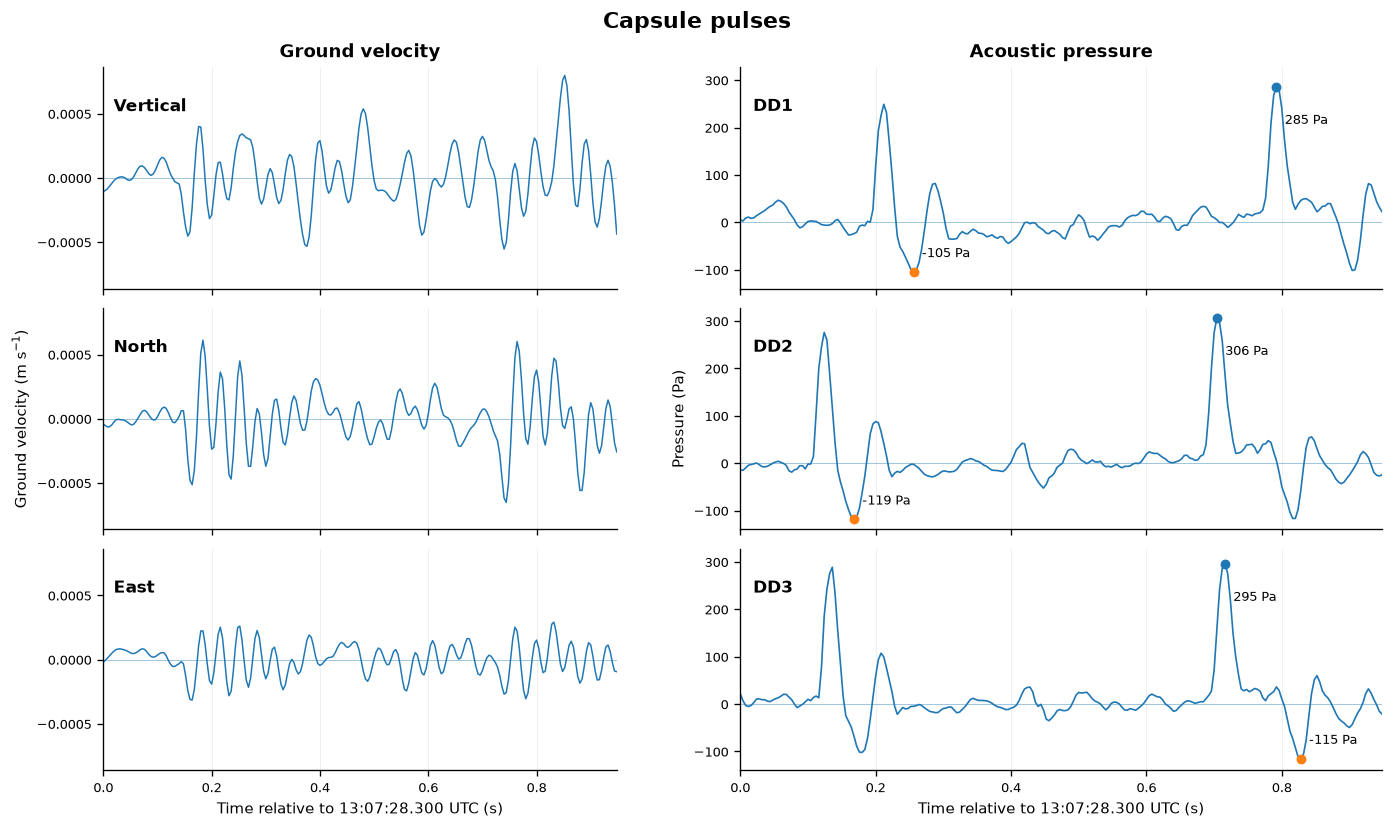

In [24]:
capsule_window_rows = key_event_windows.loc[
    key_event_windows["event"]
    .astype(str)
    .str.contains("capsule", case=False, na=False)
].copy()

if capsule_window_rows.empty:
    raise ValueError(
        "Notebook 11 exported no capsule measurement windows"
    )

CAPSULE_START = UTCDateTime(
    str(capsule_window_rows["window_start_utc"].min())
)
CAPSULE_END = UTCDateTime(
    str(capsule_window_rows["window_end_utc"].max())
)

st_capsule = st_corr.copy().trim(
    CAPSULE_START,
    CAPSULE_END,
)
capsule_pressures = key_event_pressures.loc[
    key_event_pressures["event"]
    .astype(str)
    .str.contains("capsule", case=False, na=False)
].copy()

fig, axes = plot_main_explosion(
    st_capsule,
    reference_time=CAPSULE_START,
    pressure_results=capsule_pressures,
    title="Capsule pulses",
    outfile=OUTDIR / "capsule_explosion_waveforms.png",
)


## 10. Load synchronized video/audio track

The audio track is treated as an approximate source-time reference, not an independent calibrated acoustic sensor. If `librosa` or the MP3 file is unavailable, the rest of the notebook still works without audio.


In [25]:
def load_video_audio_as_stream(
    audio_file: Path,
    starttime: UTCDateTime,
    network="YT",
    station="SYNC",
    channel="AUD",
) -> Stream:
    """Load a WAV/MP3 file as one ObsPy trace."""
    try:
        import librosa
    except Exception as exc:
        raise ImportError(
            "librosa is required to load synchronized video audio"
        ) from exc

    samples, sampling_rate = librosa.load(audio_file, sr=None)
    trace = Trace(data=np.asarray(samples, dtype=np.float32))
    trace.stats.sampling_rate = sampling_rate
    trace.stats.network = network
    trace.stats.station = station
    trace.stats.location = ""
    trace.stats.channel = channel
    trace.stats.starttime = starttime
    return Stream([trace])


def prepare_audio_for_plot(
    st_audio: Stream,
    zoom_start: UTCDateTime | None = None,
    zoom_end: UTCDateTime | None = None,
    freqmin: float | None = None,
    freqmax: float | None = None,
    audio_time_shift_s: float | None = None,
    demean: bool = True,
    normalize: bool = True,
    zerophase: bool = False,
    corners: int = 4,
) -> Stream:
    sta = st_audio.copy()
    for trace in sta:
        if demean:
            trace.detrend("demean")
        if freqmin is not None and freqmax is not None:
            trace.filter(
                "bandpass",
                freqmin=freqmin,
                freqmax=freqmax,
                corners=corners,
                zerophase=bool(zerophase),
            )
        if audio_time_shift_s is not None:
            trace.stats.starttime += audio_time_shift_s
        if zoom_start is not None and zoom_end is not None:
            trace.trim(zoom_start, zoom_end, pad=False)
        if normalize:
            trace.normalize()
    return sta


AUDIO_FILE = Path(
    video_sync.get(
        "extracted_audio_wav",
        config.OUTPUT_DIR
        / "13_synchronized_video"
        / "13_youtube_audio_render_interval.wav",
    )
).expanduser()

st_audio_raw = Stream()
if AUDIO_FILE.exists():
    audio_start_value = video_sync.get(
        "audio_start_utc",
        video_sync.get("render_start_utc", str(EXPLOSION_TIME)),
    )
    AUDIO_STARTTIME = UTCDateTime(str(audio_start_value))
    st_audio_raw = load_video_audio_as_stream(
        AUDIO_FILE,
        AUDIO_STARTTIME,
    )
    print("Loaded synchronized audio:", AUDIO_FILE)
else:
    warnings.warn(
        f"Synchronized audio product not found: {AUDIO_FILE}. "
        "Audio-dependent figures will be skipped."
    )


Loaded synchronized audio: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/13_synchronized_video/13_youtube_audio_render_interval.wav


In [26]:
# Additional camera-audio experiments were removed from the production
# figure notebook. Notebook 13 owns audio extraction and synchronization.


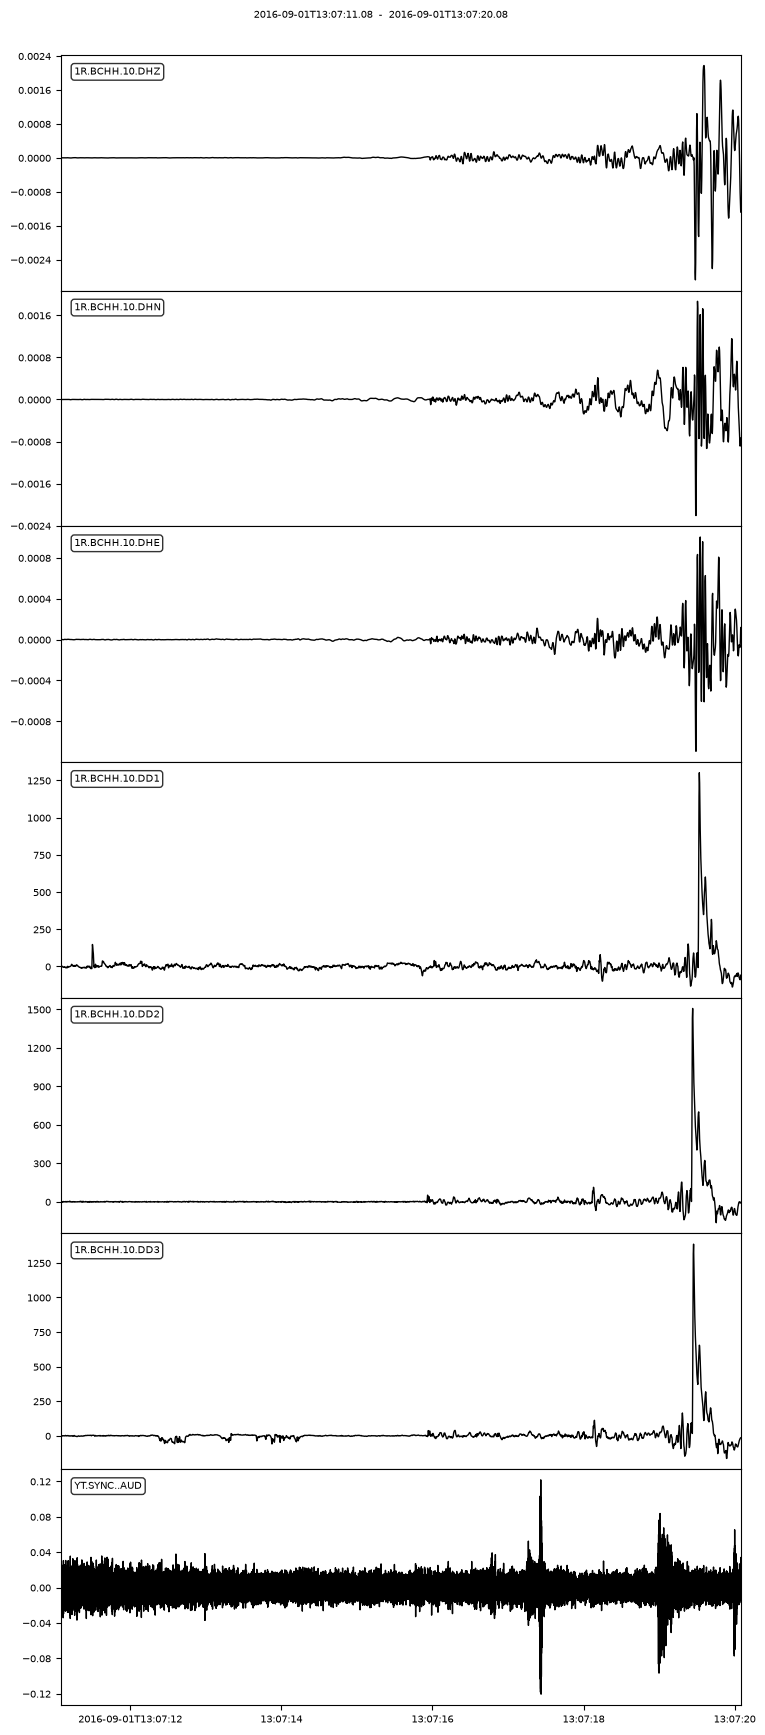

In [27]:
if len(st_audio_raw):
    (st_corr + st_audio_raw).plot(
        starttime=EXPLOSION_TIME - 1,
        endtime=EXPLOSION_TIME + 8,
        equal_scale=False,
    )


## 11. Zoom-figure utilities

The same function can make either:

- **Observed-time plot**: traces remain in UTC; dashed arrival ticks show expected acoustic arrivals.
- **Reduced-time plot**: traces are shifted earlier by travel time; source-time red lines should align with arrivals if the assumed propagation speed and source picks are correct.


## 12. Build the zoom stream and figure

Set `REDUCE_TIME=False` to inspect observed UTC arrival times. Set `REDUCE_TIME=True` to shift traces into source time using the effective acoustic speed computed above.


In [28]:
def build_zoom_stream(
    stcentaur: Stream,
    staudio: Stream,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    zerophase: bool,
    infra_freqmin: float = 0.05,
    infra_freqmax: float = 120.0,
    seis_freqmin: float = 0.05,
    seis_freqmax: float = 120.0,
    audio_freqmin: float = 1000.0,
    audio_freqmax: float = 2000.0,
    corners: int = 4,
    pad_seconds: float = 10.0,
) -> Stream:
    """Build the filtered zoom stream, including audio, for one zerophase setting."""
    zoom_infra_filter = bandpass_filter_dict(
        freqmin=infra_freqmin,
        freqmax=infra_freqmax,
        corners=corners,
        zerophase=zerophase,
    )
    zoom_seis_filter = bandpass_filter_dict(
        freqmin=seis_freqmin,
        freqmax=seis_freqmax,
        corners=corners,
        zerophase=zerophase,
    )

    # Rebuild zoom data from response-corrected traces, not from the already filtered overview stream.
    st_zoom_local = preprocess_display_stream(
        stcentaur,
        starttime=zoom_start - pad_seconds,
        endtime=zoom_end + pad_seconds,
        infra_filter=zoom_infra_filter,
        seis_filter=zoom_seis_filter,
    )

    # Audio stays in its own clock convention here. Reduced-time shifting handles
    # audio_delay_s later in one place.
    st_audio_zoom_local = prepare_audio_for_plot(
        staudio,
        zoom_start=zoom_start - pad_seconds,
        zoom_end=zoom_end + pad_seconds,
        freqmin=audio_freqmin,
        freqmax=audio_freqmax,
        normalize=True,
        zerophase=zerophase,
        corners=corners,
    )

    return st_audio_zoom_local + st_zoom_local


def channel_delay_s(
    channel: str,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
) -> float:
    """
    Return propagation delay for one plotted channel.

    For BCHH we assume both infrasound and HH seismic channels record
    the ground-coupled airwave, so all physical BCHH channels use the
    acoustic travel time.

    Audio is treated separately because it may already be synchronized
    to video/source time, or may have a separate manual clock offset.
    """
    ch = channel.upper()

    if is_audio_channel(ch):
        return audio_delay_s

    if ch in sensor_distances_m:
        return sensor_distances_m[ch] / acoustic_speed_mps

    return 0.0


def reduce_stream_to_source_time_for_zoom(
    st: Stream,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
) -> Stream:
    """
    Shift traces from observed UTC into reduced/source time.

    After this correction, an airwave travelling at acoustic_speed_mps
    should align with the source event time.
    """
    st_red = st.copy()

    for tr in st_red:
        delay = channel_delay_s(
            channel=tr.stats.channel,
            sensor_distances_m=sensor_distances_m,
            acoustic_speed_mps=acoustic_speed_mps,
            audio_delay_s=audio_delay_s,
        )

        print(f"Reducing {tr.id} by {delay:.4f} s")
        tr.stats.starttime -= delay

    return st_red


def make_zoom_figure_simple(
    st: Stream,
    outfile_base: Path,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
    event_window_s: float,
    reduced_time: bool = False,
    show_source_times: bool = True,
    show_predicted_arrivals: bool = True,
    show_event_windows: bool = False,
    normalize_by_group: bool = False,
    clip: float = 4.0,
    trace_gain: float = 0.18,
):
    """
    Plot BCHH zoom figure.

    Timing convention
    -----------------
    If reduced_time is False:
        traces are shown in observed UTC.
        predicted arrivals are plotted at source_time + travel_time.

    If reduced_time is True:
        traces have already had travel times removed.
        source times are plotted directly.
    """
    if len(st) == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.2))

    offsets = np.arange(len(st))[::-1].astype(float)
    channel_labels = []
    channel_y = {}

    infra_scales = [
        robust_scale(tr.data, percentile=99.5)
        for tr in st
        if is_infrasound_channel(tr.stats.channel)
    ]
    seis_scales = [
        robust_scale(tr.data, percentile=99.5)
        for tr in st
        if is_seismic_channel(tr.stats.channel)
    ]

    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        channel_y[ch] = y0

        trc = tr.copy().trim(zoom_start, zoom_end, pad=True, fill_value=0)

        t = trace_time_array_datetime64(trc)
        data = np.nan_to_num(
            trc.data.astype(float),
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        if normalize_by_group:
            if is_audio_channel(ch):
                scale = robust_scale(data, percentile=99.5)
            elif is_infrasound_channel(ch):
                scale = group_scale_infra
            else:
                scale = group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.5)

        if scale <= 0 or not np.isfinite(scale):
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, "-", color="black", lw=0.55, rasterized=True, zorder=12)

        if is_audio_channel(ch):
            channel_labels.append("Audio\n1–2 kHz")
        else:
            channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-0.7, len(st) - 0.25)
    ax.set_xlim(
        mdates.date2num(zoom_start.datetime),
        mdates.date2num(zoom_end.datetime),
    )

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=1))

    ax.grid(axis="x", which="major", color="0.78", lw=0.8, zorder=1)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4, zorder=1)
    ax.set_xlabel("Time on 1 September 2016 (UTC)")

    if len(st) >= 6:
        ax.axhline(2.5, color="0.55", lw=0.8, zorder=10)

    def draw_short_vline(x, y0, half_height=0.38, **kwargs):
        ax.vlines(x, y0 - half_height, y0 + half_height, **kwargs)

    ytop = len(st) - 0.15

    for label, source_time in source_events.items():

        if show_source_times and zoom_start <= source_time <= zoom_end:
            x = mdates.date2num(source_time.datetime)

            ax.axvline(
                x,
                color="firebrick",
                lw=1.1,
                alpha=0.85,
                zorder=25,
            )

            ax.text(
                x,
                ytop,
                label,
                rotation=90,
                ha="center",
                va="top",
                fontsize=8,
                color="firebrick",
                alpha=0.90,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    pad=1.0,
                ),
                clip_on=False,
                zorder=30,
            )

        for ch, y0 in channel_y.items():

            if reduced_time:
                arrival_time = source_time
            else:
                delay = channel_delay_s(
                    channel=ch,
                    sensor_distances_m=sensor_distances_m,
                    acoustic_speed_mps=acoustic_speed_mps,
                    audio_delay_s=audio_delay_s,
                )
                arrival_time = source_time + delay

            if show_event_windows:
                t_left = arrival_time - event_window_s / 2
                t_right = arrival_time + event_window_s / 2

                if t_right >= zoom_start and t_left <= zoom_end:
                    ax.fill_betweenx(
                        [y0 - 0.42, y0 + 0.42],
                        mdates.date2num(max(t_left, zoom_start).datetime),
                        mdates.date2num(min(t_right, zoom_end).datetime),
                        color="0.75",
                        alpha=0.35,
                        lw=0,
                        zorder=18,
                    )

            if show_predicted_arrivals and zoom_start <= arrival_time <= zoom_end:
                x = mdates.date2num(arrival_time.datetime)

                color = "firebrick" if is_infrasound_channel(ch) else "0.25"

                draw_short_vline(
                    x,
                    y0,
                    color=color,
                    lw=0.9,
                    linestyles="--",
                    alpha=0.6,
                    zorder=22,
                )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.15)

    for ext in ["png", "pdf"]:
        fig.savefig(
            outfile_base.with_suffix(f".{ext}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )

    return fig, ax


def make_zoom_variant(
    stcentaur: Stream,
    staudio: Stream,
    output_dir: Path,
    zerophase: bool,
    reduce_time: bool,
    window_start: UTCDateTime,
    window_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
    event_window_s: float,
    outfile_stem: str = "fig03_bchh_20s_zoom_with_audio",
    show: bool = True,
    zoom_filter_settings: dict | None = None,
    plot_settings: dict | None = None,
):
    """Build and plot one zoom figure for a zerophase/reduced-time combination.

    All quantities that affect the result are arguments rather than hidden globals.
    """
    if zoom_filter_settings is None:
        zoom_filter_settings = {}
    if plot_settings is None:
        plot_settings = {}

    st_zoom_local = build_zoom_stream(
        stcentaur=stcentaur,
        staudio=staudio,
        zoom_start=window_start,
        zoom_end=window_end,
        zerophase=zerophase,
        **zoom_filter_settings,
    )

    if reduce_time:
        st_zoom_plot_local = reduce_stream_to_source_time_for_zoom(
            st=st_zoom_local,
            sensor_distances_m=sensor_distances_m,
            acoustic_speed_mps=acoustic_speed_mps,
            audio_delay_s=audio_delay_s,
        )
        timing_tag = "reduced"
    else:
        st_zoom_plot_local = st_zoom_local.copy()
        timing_tag = "observed"

    st_zoom_plot_local.trim(window_start, window_end, pad=False)

    outfile_local = output_dir / f"{outfile_stem}_{timing_tag}_{zerophase_tag(zerophase)}"

    print(
        f"Plotting {outfile_local.name}: "
        f"ZEROPHASE={zerophase}, REDUCE_TIME={reduce_time}, "
        f"acoustic speed={acoustic_speed_mps:.1f} m/s"
    )

    fig, ax = make_zoom_figure_simple(
        st=st_zoom_plot_local,
        outfile_base=outfile_local,
        zoom_start=window_start,
        zoom_end=window_end,
        source_events=source_events,
        sensor_distances_m=sensor_distances_m,
        acoustic_speed_mps=acoustic_speed_mps,
        audio_delay_s=audio_delay_s,
        event_window_s=event_window_s,
        reduced_time=reduce_time,
        show_source_times=plot_settings.get("show_source_times", True),
        show_predicted_arrivals=plot_settings.get("show_predicted_arrivals", not reduce_time),
        show_event_windows=plot_settings.get("show_event_windows", False),
        normalize_by_group=plot_settings.get("normalize_by_group", False),
        clip=plot_settings.get("clip", 1.2),
        trace_gain=plot_settings.get("trace_gain", 0.4),
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "zerophase": zerophase,
        "reduce_time": reduce_time,
        "stream": st_zoom_plot_local,
        "outfile": outfile_local,
        "fig": fig,
        "ax": ax,
    }



Using acoustic speed 351.96 m/s from Notebook 08 Quality A coherence-weighted result
Using audio delay 0.000 s from Notebook 13 synchronization metadata
Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.0913 s
Reducing 1R.BCHH.10.DD2 by 4.0014 s
Reducing 1R.BCHH.10.DD3 by 4.0142 s
Reducing 1R.BCHH.10.DHE by 4.0342 s
Reducing 1R.BCHH.10.DHN by 4.0342 s
Reducing 1R.BCHH.10.DHZ by 4.0342 s
Plotting fig03_bchh_30s_zoom_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=352.0 m/s


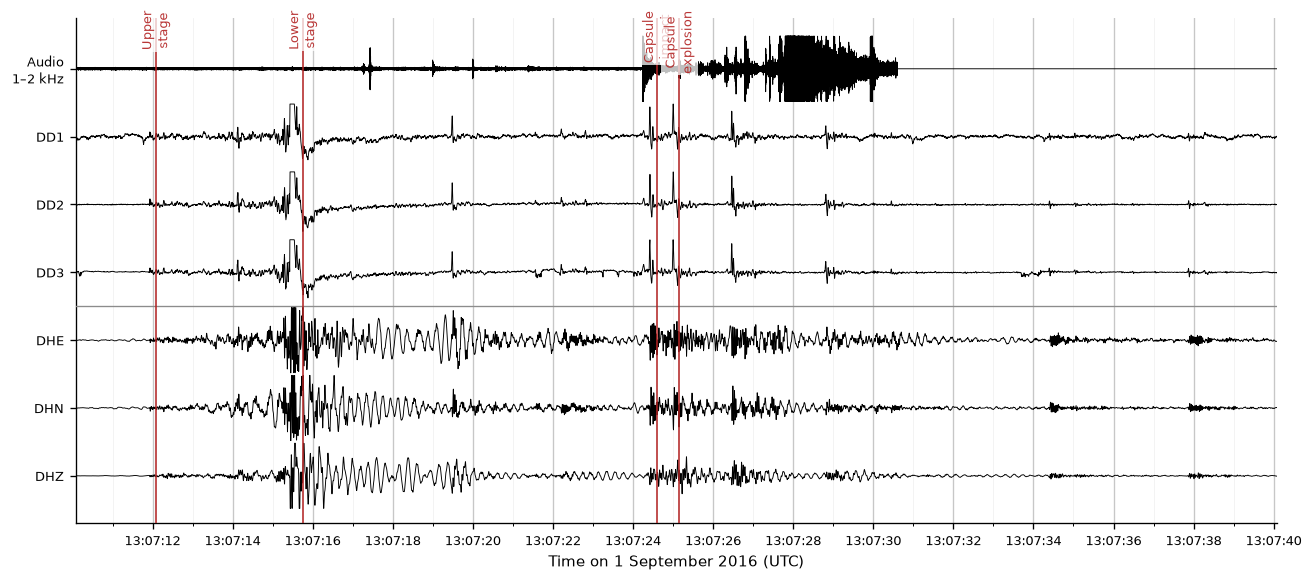

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.0913 s
Reducing 1R.BCHH.10.DD2 by 4.0014 s
Reducing 1R.BCHH.10.DD3 by 4.0142 s
Reducing 1R.BCHH.10.DHE by 4.0342 s
Reducing 1R.BCHH.10.DHN by 4.0342 s
Reducing 1R.BCHH.10.DHZ by 4.0342 s
Plotting fig03_bchh_30s_zoom_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=352.0 m/s


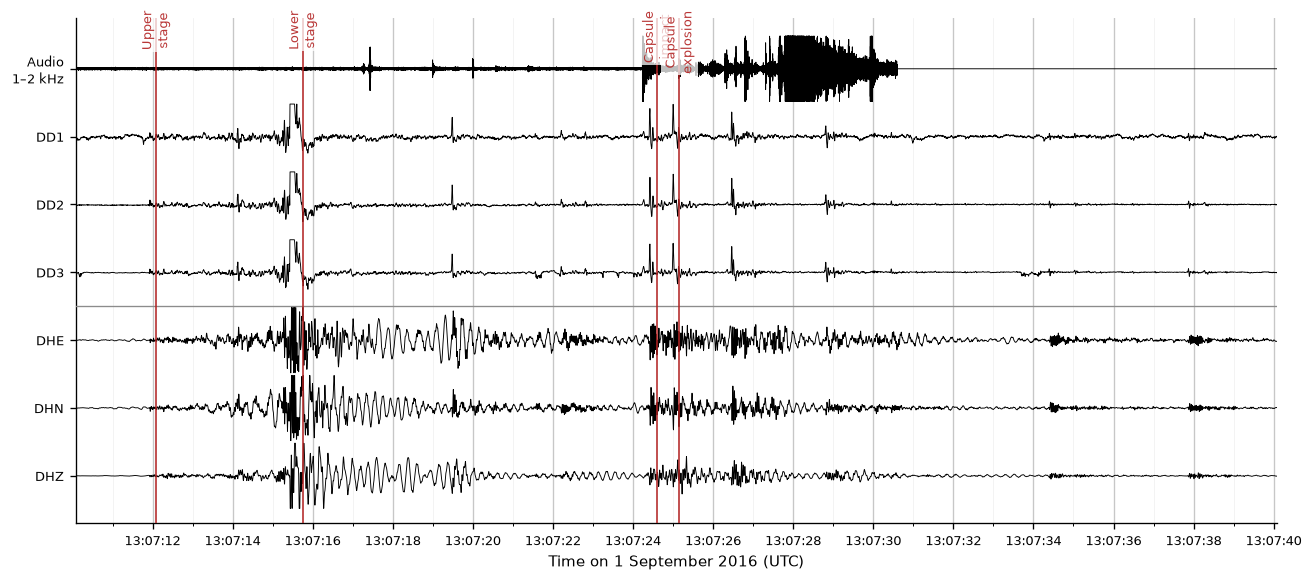

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.0913 s
Reducing 1R.BCHH.10.DD2 by 4.0014 s
Reducing 1R.BCHH.10.DD3 by 4.0142 s
Reducing 1R.BCHH.10.DHE by 4.0342 s
Reducing 1R.BCHH.10.DHN by 4.0342 s
Reducing 1R.BCHH.10.DHZ by 4.0342 s
Plotting fig03_initial_failure_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=352.0 m/s


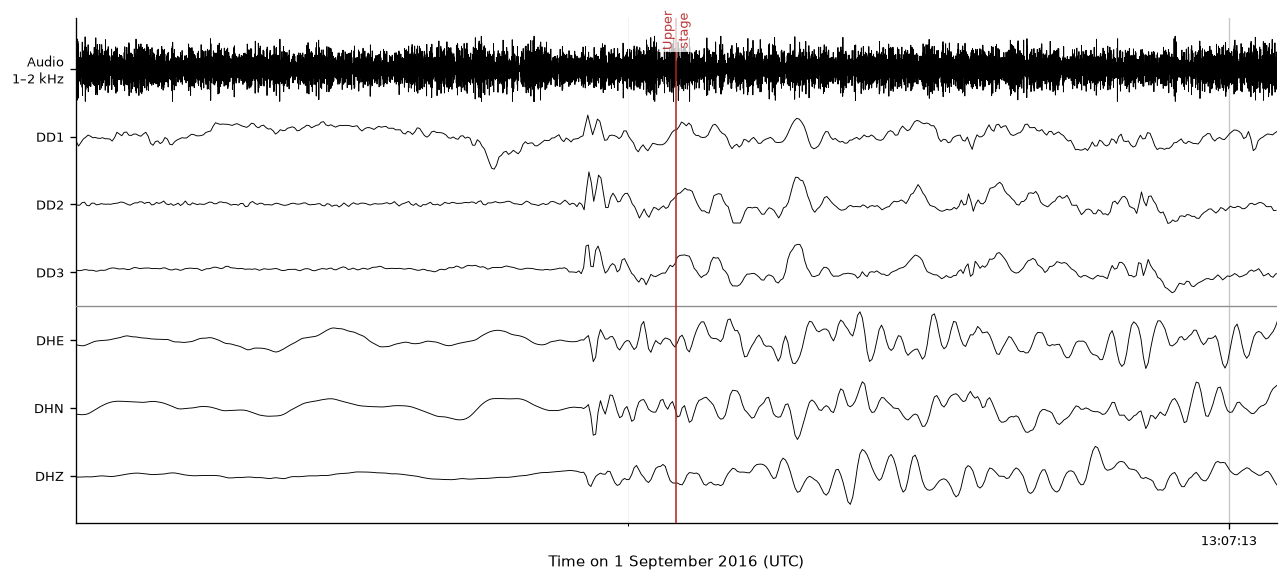

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.0913 s
Reducing 1R.BCHH.10.DD2 by 4.0014 s
Reducing 1R.BCHH.10.DD3 by 4.0142 s
Reducing 1R.BCHH.10.DHE by 4.0342 s
Reducing 1R.BCHH.10.DHN by 4.0342 s
Reducing 1R.BCHH.10.DHZ by 4.0342 s
Plotting fig03_initial_failure_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=352.0 m/s


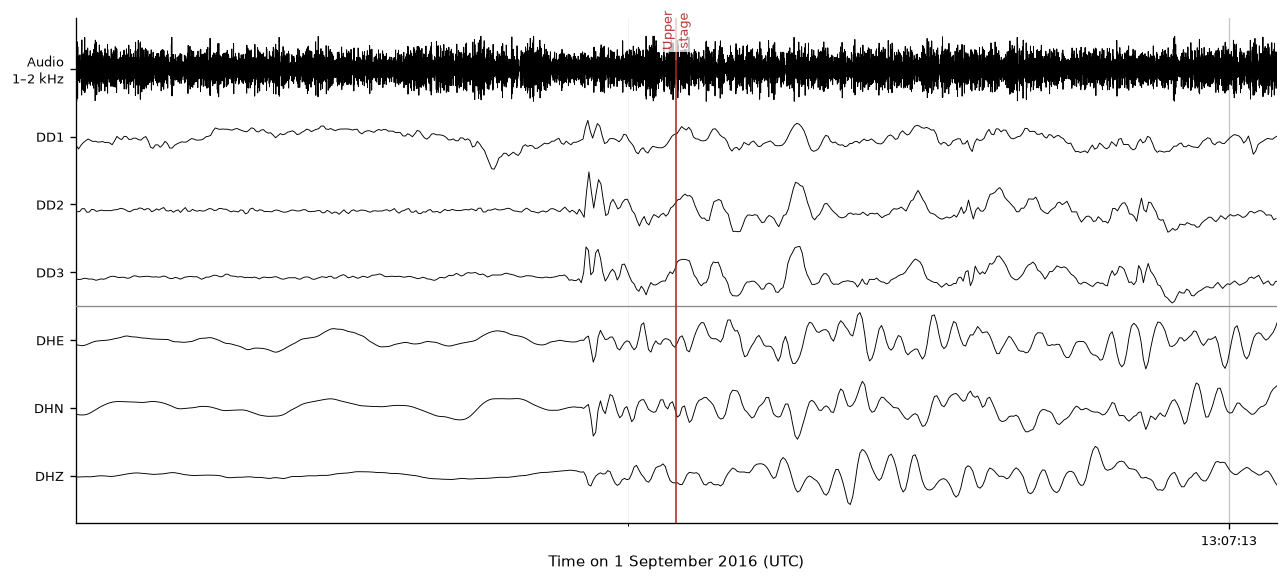

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.0913 s
Reducing 1R.BCHH.10.DD2 by 4.0014 s
Reducing 1R.BCHH.10.DD3 by 4.0142 s
Reducing 1R.BCHH.10.DHE by 4.0342 s
Reducing 1R.BCHH.10.DHN by 4.0342 s
Reducing 1R.BCHH.10.DHZ by 4.0342 s
Plotting fig03_first_stage_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=352.0 m/s


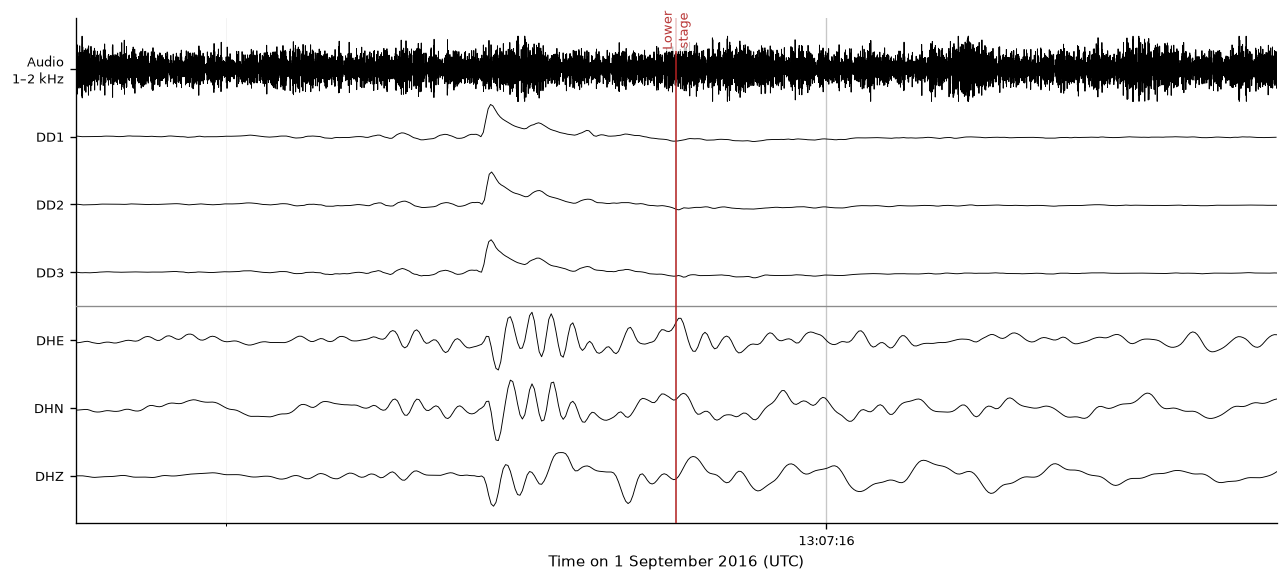

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.0913 s
Reducing 1R.BCHH.10.DD2 by 4.0014 s
Reducing 1R.BCHH.10.DD3 by 4.0142 s
Reducing 1R.BCHH.10.DHE by 4.0342 s
Reducing 1R.BCHH.10.DHN by 4.0342 s
Reducing 1R.BCHH.10.DHZ by 4.0342 s
Plotting fig03_first_stage_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=352.0 m/s


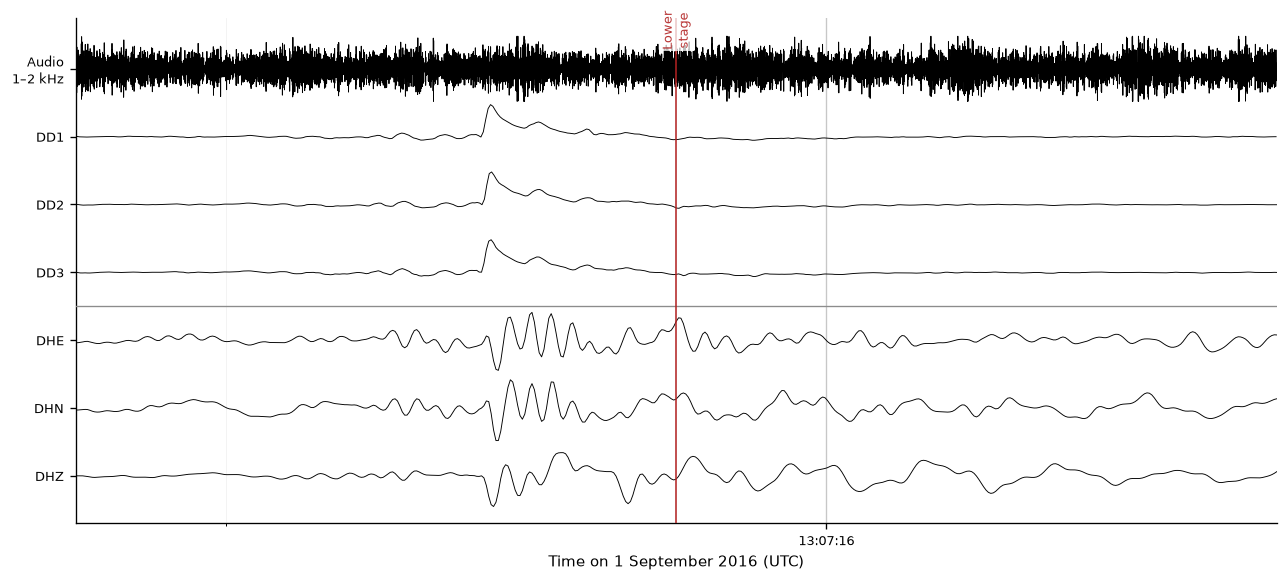

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.0913 s
Reducing 1R.BCHH.10.DD2 by 4.0014 s
Reducing 1R.BCHH.10.DD3 by 4.0142 s
Reducing 1R.BCHH.10.DHE by 4.0342 s
Reducing 1R.BCHH.10.DHN by 4.0342 s
Reducing 1R.BCHH.10.DHZ by 4.0342 s
Plotting fig03_capsule_impact_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=352.0 m/s


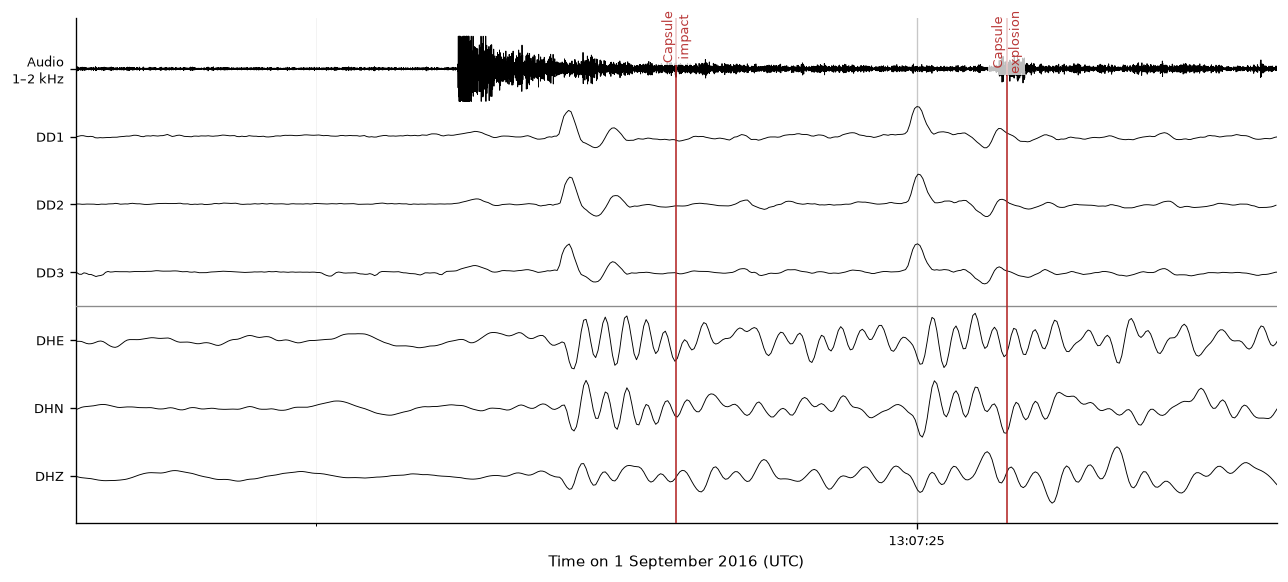

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.0913 s
Reducing 1R.BCHH.10.DD2 by 4.0014 s
Reducing 1R.BCHH.10.DD3 by 4.0142 s
Reducing 1R.BCHH.10.DHE by 4.0342 s
Reducing 1R.BCHH.10.DHN by 4.0342 s
Reducing 1R.BCHH.10.DHZ by 4.0342 s
Plotting fig03_capsule_impact_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=352.0 m/s


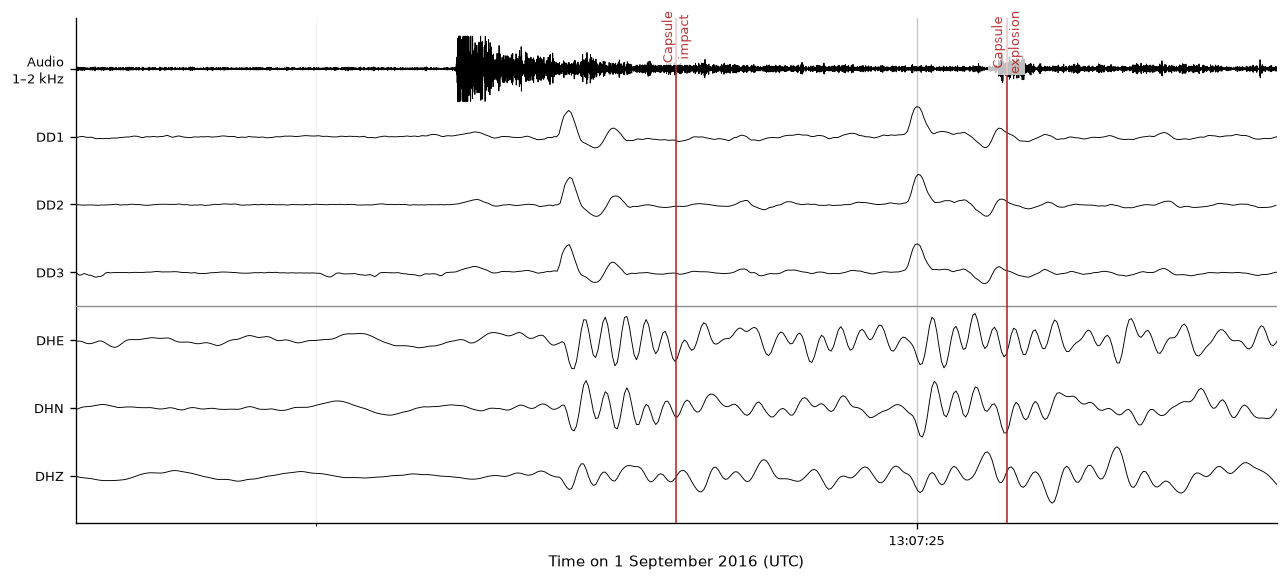

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.0913 s
Reducing 1R.BCHH.10.DD2 by 4.0014 s
Reducing 1R.BCHH.10.DD3 by 4.0142 s
Reducing 1R.BCHH.10.DHE by 4.0342 s
Reducing 1R.BCHH.10.DHN by 4.0342 s
Reducing 1R.BCHH.10.DHZ by 4.0342 s
Plotting fig03_capsule_explosion_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=352.0 m/s


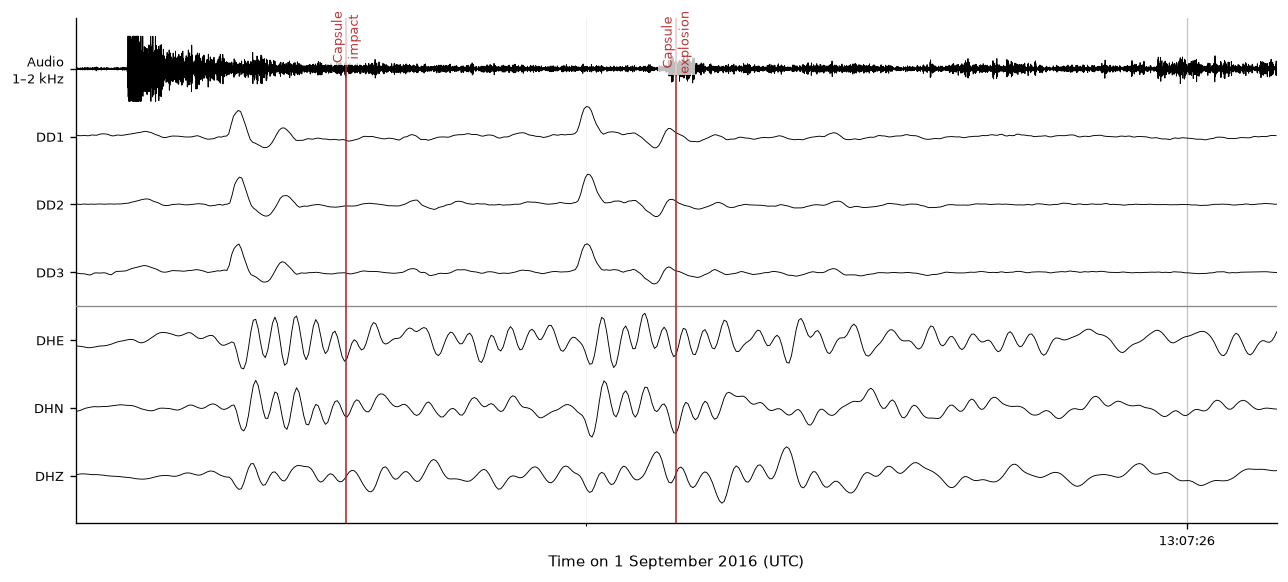

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.0913 s
Reducing 1R.BCHH.10.DD2 by 4.0014 s
Reducing 1R.BCHH.10.DD3 by 4.0142 s
Reducing 1R.BCHH.10.DHE by 4.0342 s
Reducing 1R.BCHH.10.DHN by 4.0342 s
Reducing 1R.BCHH.10.DHZ by 4.0342 s
Plotting fig03_capsule_explosion_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=352.0 m/s


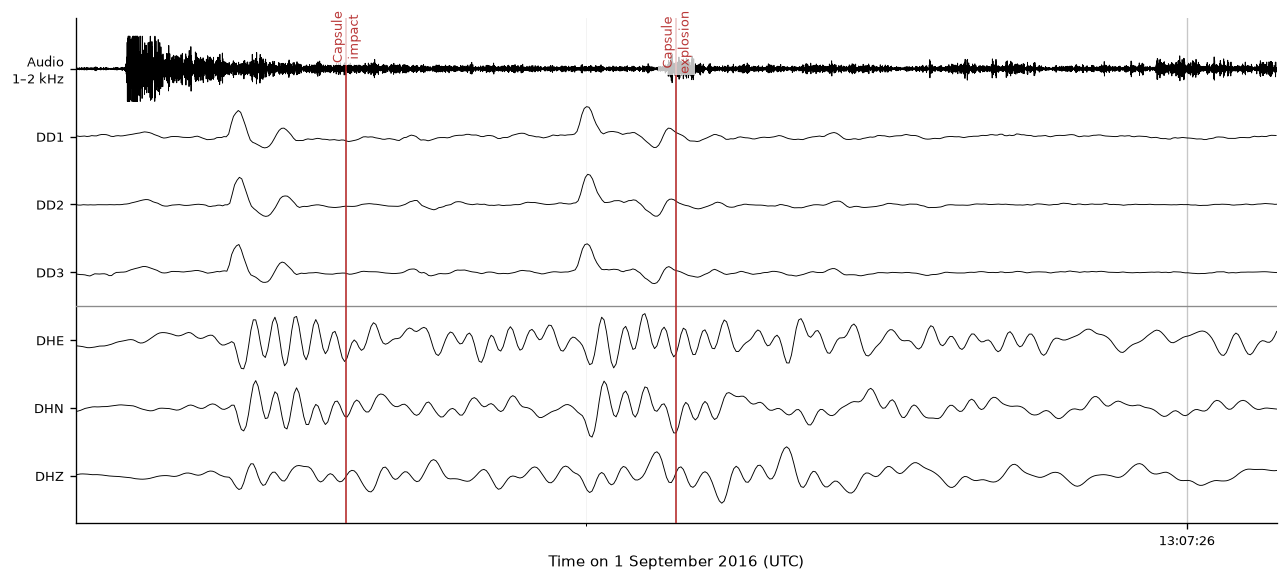

Generated close-up figures:
  /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/14_paper_figures/fig03_initial_failure_closeup_with_audio_reduced_zp_false
  /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/14_paper_figures/fig03_initial_failure_closeup_with_audio_reduced_zp_true
  /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/14_paper_figures/fig03_first_stage_closeup_with_audio_reduced_zp_false
  /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/14_paper_figures/fig03_first_stage_closeup_with_audio_reduced_zp_true
  /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/

In [29]:
REDUCE_TIME = True

zoom_start = EXPLOSION_TIME - 2
zoom_end = EXPLOSION_TIME + 28

speed_to_use = ADOPTED_ACOUSTIC_SPEED_MPS
audio_delay_to_use = float(
    video_sync.get(
        "audio_delay_s",
        video_sync.get("audio_propagation_delay_s", 0.0),
    )
)

print(
    f"Using acoustic speed {speed_to_use:.2f} m/s "
    f"from {ADOPTED_SPEED_SOURCE}"
)
print(
    f"Using audio delay {audio_delay_to_use:.3f} s "
    "from Notebook 13 synchronization metadata"
)

zoom_filter_settings = {
    "infra_freqmin": 0.05,
    "infra_freqmax": 120.0,
    "seis_freqmin": 0.05,
    "seis_freqmax": 120.0,
    "audio_freqmin": 1000.0,
    "audio_freqmax": 2000.0,
    "corners": 4,
    "pad_seconds": 10.0,
}
zoom_plot_settings = {
    "show_source_times": True,
    "show_event_windows": False,
    "normalize_by_group": False,
    "clip": 1.2,
    "trace_gain": 0.4,
}

zoom_results = []
closeup_results = []

if len(st_audio_raw):
    zerophase_values_to_run = (
        ZEROPHASE_RUNS
        if RUN_ZEROPHASE_COMPARISON
        else [ZEROPHASE]
    )

    for zerophase in zerophase_values_to_run:
        zoom_results.append(
            make_zoom_variant(
                stcentaur=st_ordered,
                staudio=st_audio_raw,
                output_dir=OUTDIR,
                zerophase=zerophase,
                reduce_time=REDUCE_TIME,
                window_start=zoom_start,
                window_end=zoom_end,
                source_events=SOURCE_EVENTS,
                sensor_distances_m=SENSOR_DISTANCES_M,
                acoustic_speed_mps=speed_to_use,
                audio_delay_s=audio_delay_to_use,
                event_window_s=VIDEO_PICK_UNCERTAINTY_S,
                outfile_stem="fig03_bchh_30s_zoom_with_audio",
                show=True,
                zoom_filter_settings=zoom_filter_settings,
                plot_settings=zoom_plot_settings,
            )
        )

    # Event-centered display windows. Centers come from Notebook 02/12
    # products; only the visual half-widths are figure-layout choices.
    closeup_definitions = [
        {
            "name": "initial_failure",
            "center": EXPLOSION_TIME,
            "half_width_s": 1.0,
            "outfile_stem": (
                "fig03_initial_failure_closeup_with_audio"
            ),
        },
        {
            "name": "first_stage",
            "center": FIRST_STAGE,
            "half_width_s": 1.0,
            "outfile_stem": (
                "fig03_first_stage_closeup_with_audio"
            ),
        },
        {
            "name": "capsule_impact",
            "center": CAPSULE_IMPACT,
            "half_width_s": 1.0,
            "outfile_stem": (
                "fig03_capsule_impact_closeup_with_audio"
            ),
        },
        {
            "name": "capsule_explosion",
            "center": CAPSULE_EXPLOSION,
            "half_width_s": 1.0,
            "outfile_stem": (
                "fig03_capsule_explosion_closeup_with_audio"
            ),
        },
    ]

    if precursor1 is not None:
        closeup_definitions.insert(
            1,
            {
                "name": "precursor1",
                "center": precursor1,
                "half_width_s": 1.0,
                "outfile_stem": (
                    "fig03_precursor1_closeup_with_audio"
                ),
            },
        )

    if precursor2 is not None:
        closeup_definitions.insert(
            2,
            {
                "name": "precursor2",
                "center": precursor2,
                "half_width_s": 1.0,
                "outfile_stem": (
                    "fig03_precursor2_closeup_with_audio"
                ),
            },
        )

    for definition in closeup_definitions:
        for zerophase in zerophase_values_to_run:
            closeup_results.append(
                make_zoom_variant(
                    stcentaur=st_ordered,
                    staudio=st_audio_raw,
                    output_dir=OUTDIR,
                    zerophase=zerophase,
                    reduce_time=REDUCE_TIME,
                    window_start=(
                        definition["center"]
                        - definition["half_width_s"]
                    ),
                    window_end=(
                        definition["center"]
                        + definition["half_width_s"]
                    ),
                    source_events=SOURCE_EVENTS,
                    sensor_distances_m=SENSOR_DISTANCES_M,
                    acoustic_speed_mps=speed_to_use,
                    audio_delay_s=audio_delay_to_use,
                    event_window_s=VIDEO_PICK_UNCERTAINTY_S,
                    outfile_stem=definition["outfile_stem"],
                    show=True,
                    zoom_filter_settings=zoom_filter_settings,
                    plot_settings=zoom_plot_settings,
                )
            )

    st_zoom_plot = zoom_results[0]["stream"]
    outfile = zoom_results[0]["outfile"]

    print("Generated close-up figures:")
    for result in closeup_results:
        print(" ", result["outfile"])
else:
    print(
        "Skipping audio zoom figures because "
        "Notebook 13 audio is unavailable."
    )


## 14. Figure-generation provenance


In [30]:
figure_provenance = {
    "producer_notebook": "14_generate_paper_figures.ipynb",
    "analysis_configuration": str(ANALYSIS_CONFIG_FILE),
    "weather_summary": str(WEATHER_FILE),
    "catalogue": str(CATALOGUE_FILE),
    "geometry": str(GEOMETRY_FILE),
    "waveform_stream": str(BASELINE_STREAM_FILE),
    "planar_results": str(PLANAR_RESULTS_FILE),
    "planar_summary": str(PLANAR_SUMMARY_FILE),
    "key_event_pressures": str(KEY_EVENT_PRESSURES_FILE),
    "key_event_windows": str(KEY_EVENT_WINDOWS_FILE),
    "key_event_metadata": str(KEY_EVENT_METADATA_FILE),
    "video_sync": str(VIDEO_SYNC_FILE),
    "adopted_acoustic_speed_mps": ADOPTED_ACOUSTIC_SPEED_MPS,
    "adopted_speed_source": ADOPTED_SPEED_SOURCE,
    "channels": CHANNEL_ORDER,
    "tremor_start_utc": (
        TREMOR_START.isoformat()
        if TREMOR_START is not None
        else None
    ),
    "tremor_end_utc": (
        TREMOR_END.isoformat()
        if TREMOR_END is not None
        else None
    ),
}
provenance_file = OUTDIR / "14_figure_generation_provenance.json"
provenance_file.write_text(
    json.dumps(figure_provenance, indent=2) + "\n"
)
display(pd.Series(figure_provenance, name="value").to_frame())
print("Wrote:", provenance_file)


,value
producer_notebook,14_generate_paper_figures.ipynb
analysis_configuration,/Users/thompsong/Library/CloudStorage/Box-Box/...
weather_summary,/Users/thompsong/Library/CloudStorage/Box-Box/...
catalogue,/Users/thompsong/Library/CloudStorage/Box-Box/...
geometry,/Users/thompsong/Library/CloudStorage/Box-Box/...
waveform_stream,/Users/thompsong/Library/CloudStorage/Box-Box/...
planar_results,/Users/thompsong/Library/CloudStorage/Box-Box/...
planar_summary,/Users/thompsong/Library/CloudStorage/Box-Box/...
key_event_pressures,/Users/thompsong/Library/CloudStorage/Box-Box/...
key_event_windows,/Users/thompsong/Library/CloudStorage/Box-Box/...


Wrote: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/14_paper_figures/14_figure_generation_provenance.json


## 13. PSD

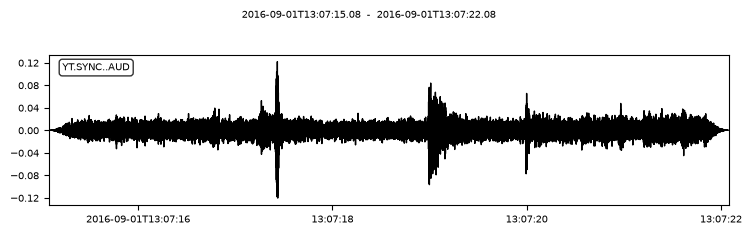

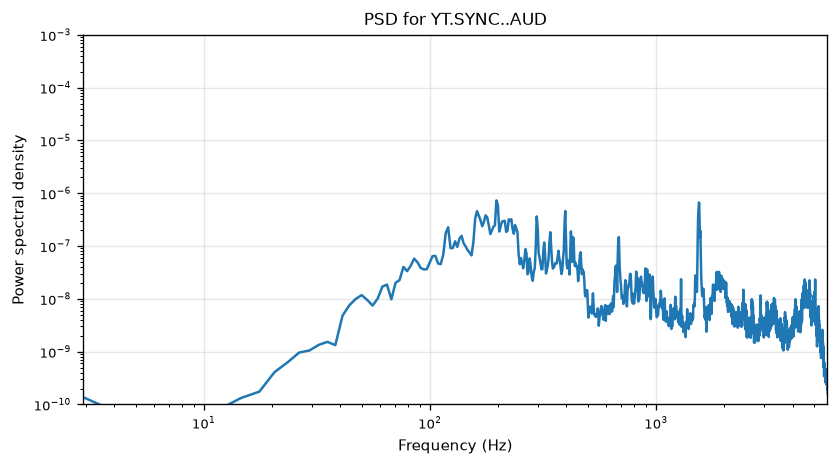

In [31]:
from scipy.signal import welch
import matplotlib.pyplot as plt
def psd_plot(st, xlims=None, ylims=None, nyquist_percentage=0.95, plot_trace=False):
    for tr in st:
        tr = tr.copy()
        tr.detrend("demean")
        tr.taper(max_percentage=0.05)
        if plot_trace:
            tr.plot()

        fs = tr.stats.sampling_rate
        highest_freq_to_plot = 0.5 * fs * nyquist_percentage
        x = tr.data.astype(float)

        f, Pxx = welch(
            x,
            fs=fs,
            nperseg=min(4096, len(x)),
            noverlap=None,
            scaling="density"
        )

        plt.figure(figsize=(8, 4))
        plt.loglog(f, Pxx)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power spectral density")
        plt.title(f"PSD for {tr.id}")
        if xlims is None:
            xlims = (f[1], highest_freq_to_plot)
        xlims = (max(xlims[0], f[1]), min(xlims[1], highest_freq_to_plot))
        plt.xlim(xlims)
        if ylims is not None:
            plt.ylim(ylims)
        plt.grid(True, alpha=0.3)
        plt.show()

st_spec = st_audio_raw.copy().trim(starttime=EXPLOSION_TIME+3, endtime=EXPLOSION_TIME+10)
psd_plot(st_spec, ylims=(1e-10, 1e-3), plot_trace=True)#, xlims=(1, 10000))